# Quantum phase transitions — mapping a phase diagram from finite chains

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 13 — Quantum phase transitions*

## 1. Introduction and motivation

A **quantum phase transition** is a qualitative change of the *ground state* of a Hamiltonian. What competes are
non-commuting terms of the Hamiltonian, and the control parameter is a coupling. Tune it, and at some
critical value the ground state reorganises qualitatively: an order parameter switches on, the gap to the first
excited state closes, correlations become long-ranged.

That is the textbook statement, and it holds **only in the limit of an infinite chain**. On the finite chains a computer
can hold, none of it is literally true:

* the ground-state energy is an analytic function of the coupling — a finite matrix has no singularities;
* the gap never closes, it only becomes small;
* no symmetry is ever broken, so the order parameter $\langle Z_j\rangle$ is exactly zero on *both* sides.

The practical problem of this notebook is therefore to **extract a sharp statement about the infinite system from
smooth data on small ones**. That is a numerical-methods question, and the answer - finite-size scaling - is the
same one used for classical Monte Carlo, for cold-atom experiments with a few hundred atoms, and for tensor-network
calculations such as those of notebook 18 (Chapter 7).

We use the **transverse-field Ising model** (TFIM) as the benchmark,

$$ H = -J\sum_{i=0}^{N-2} Z_iZ_{i+1} - h\sum_{i=0}^{N-1}X_i , \qquad (1) $$

because it is exactly solvable: we know the answer for the critical point, the exponents and the central charge,
and can therefore *grade* every numerical signature instead of merely admiring it. Only then do we point the same
tools at a model where they are harder to use.

**Road map.**

1. The model, its symmetry, and the exact results we will use as a grader (Sec. 2).
2. The tool: Lanczos restricted to a symmetry sector, which gives the ground state *and* the first excited state
   from two ground-state calculations (Sec. 3).
3. Four independent signatures of the transition, each computed and each compared with the exact answer:
   the order parameter (Sec. 4), the gap and the crossing of $N\Delta$ (Sec. 5), the entanglement entropy and the
   central charge (Sec. 6),
   and the fidelity susceptibility, which needs no order parameter at all (Sec. 7).
4. Finite-size scaling: pseudo-critical points, extrapolation to $N\to\infty$, and data collapse with the
   exponents $\nu$, $\beta$, $z$ (Sec. 8).
5. The same analysis with DMRG at $N=32$, $64$ and $128$: order parameter, central charge and the correlation
   exponent $\eta$ (Sec. 9).
6. A second universality class and a transition that finite-size scaling handles badly: the XX chain, checked
   against its free-fermion solution, with $c=1$, and the Kosterlitz-Thouless point of the XXZ chain (Sec. 10).
7. Cost, limits, takeaways, exercises (Secs. 11-13).

### What you will learn

* Why $\langle Z_j\rangle=0$ on every finite chain, and what to measure instead.
* How to get an excited state from a ground-state solver by using a symmetry.
* Four ways to see one transition, and what each costs.
* How to turn $N=8,\dots,16$ into a critical point and two exponents, and how far to trust the result.
* Why a Kosterlitz-Thouless transition defeats the same procedure, and how to recognise that from the data.

### Prerequisites

* Lanczos, restarts and symmetry sectors: [notebook 11 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/11_hamiltonians_and_ground_states.ipynb),
  Secs. 5-11; its Sec. 10.3 derives the tunnelling splitting of the ordered phase used below, and its Sec. 11 takes
  a first look at this transition at $N=8,12,16$ together with the free-fermion solution quoted there.
* Entanglement entropy from Schmidt values: [notebook 06 (Chapter 3)](../ch03_matrix_free_engine/06_states_observables_entanglement.ipynb).
* Matrix product states, MPOs and DMRG: [notebook 18 (Chapter 7)](../ch07_tensor_networks/18_mps_tebd.ipynb), Sec. 6.
* `jax.jit` and traced arguments: [notebook 01 (Chapter 1)](../ch01_computational_toolbox/01_jax_from_scratch.ipynb).
* The Jordan-Wigner mapping to free fermions, quoted without proof:
  [notebook 15 (Chapter 5)](../ch05_ground_states_and_unitary_dynamics/15_quench_dynamics_spin_chains.ipynb), Sec. 7.2.
* Optional, for one remark in Sec. 7: the quantum Fisher information of a pure state,
  [notebook 29 (Chapter 10)](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb), Sec. 6.2.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # the 52 einsum index labels a-z, A-Z

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)

def fidelity_pure(psi, phi):
    """F = |<psi|phi>|^2 between two pure states."""
    return jnp.abs(jnp.vdot(psi, phi)) ** 2


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))

def dense_hamiltonian(terms, N):
    """Dense 2^N x 2^N matrix for VALIDATION on small N -- built from the matrix-free action:
    column j of H is H|e_j>.   `jax.vmap` applies H to all basis vectors at once."""
    eye = jnp.eye(2 ** N, dtype=CDTYPE).reshape((2 ** N,) + (2,) * N)
    cols = jax.vmap(lambda e: apply_hamiltonian(terms, e).reshape(-1))(eye)
    return cols.T


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
_SPIN_MPS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1]}      # same characters as product_state
LAM_CUT = 100 * float(jnp.finfo(RDTYPE).eps)                           # Schmidt values below this are padding
@jax.jit
def mps_to_state(B):
    """Padded MPS -> state tensor (validation only, O(2^N)).  The dummy boundary bonds are index 0.
    JAX: the shapes are static, so the whole chain of N contractions is compiled once per (N, chi)."""
    psi = B[0][0]                                          # (2, chi): left boundary leg fixed to 0
    for j in range(1, B.shape[0]):
        psi = jnp.tensordot(psi, B[j], axes=([-1], [0]))
    return psi[..., 0]                                     # right boundary leg fixed to 0

def product_mps(spec, chi):
    """Product state |spec[0]> |spec[1]> ... as a padded MPS  (B[N,chi,2,chi], lam[N+1,chi]).
    MATH   B[j][0, s, 0] = v_j[s], all other entries zero;  every cut has the single Schmidt value 1.
    '0' = spin up (Z=+1), '1' = spin down (Z=-1), '+'/'-' = eigenstates of X."""
    N = len(spec)
    B = np.zeros((N, chi, 2, chi), dtype=complex)
    for j, c in enumerate(spec):
        v = np.array(_SPIN_MPS[c], dtype=complex)
        B[j, 0, :, 0] = v / np.linalg.norm(v)
    lam = np.zeros((N + 1, chi))
    lam[:, 0] = 1.0
    return jnp.asarray(B, dtype=CDTYPE), jnp.asarray(lam, dtype=RDTYPE)

def mps_expect_sites(B, lam, O):
    """<O_j> for ALL sites j at once.   MATH  theta_j = lam[j] B[j];  <O_j> = sum theta*[a,t,b] O[t,s] theta[a,s,b].
    COST O(N chi^2).  The letter j in the einsum is a batch index (one independent contraction per site)."""
    theta = lam[:-1, :, None, None] * B
    return jnp.real(jnp.einsum("jatb,ts,jasb->j", jnp.conj(theta), jnp.asarray(O, dtype=B.dtype), theta))

def mps_entropies(lam):
    """Entanglement entropy (bits) of every cut, directly from the stored Schmidt values:
    S_j = -sum_k lam[j,k]^2 log2 lam[j,k]^2   (0 log 0 := 0 handles the zero padding)."""
    p = lam ** 2
    return -jnp.sum(jnp.where(p > 0, p * jnp.log2(jnp.where(p > 0, p, 1.0)), 0.0), axis=1)

def mps_correlator(B, lam, O, i, P, j):
    """<O_i P_j> for i < j (static ints) with a transfer-matrix sweep between the two sites.  COST O((j-i) chi^3).
    O and P must be Hermitian: the product O_i P_j on two different sites is then Hermitian and its expectation value
    real, which is what is returned (the real part; a non-Hermitian pair such as sigma+ sigma- would lose its
    imaginary part).  i >= j raises ValueError (i == j is the single-site <O P>, use mps_expect_sites)."""
    i, j = int(i), int(j)
    if not 0 <= i < j < B.shape[0]:                                   # j <= i silently returned a wrong number
        raise ValueError(f"mps_correlator needs 0 <= i < j < {B.shape[0]}, got i={i}, j={j}")
    O, P = jnp.asarray(O, dtype=B.dtype), jnp.asarray(P, dtype=B.dtype)
    theta = lam[i][:, None, None] * B[i]
    E = jnp.einsum("atb,ts,asc->bc", jnp.conj(theta), O, theta)       # open legs: right bonds (bra b, ket c)
    for k in range(i + 1, j):
        E = jnp.einsum("bc,bsd,cse->de", E, jnp.conj(B[k]), B[k])     # push through site k
    return jnp.real(jnp.einsum("bc,btd,ts,csd->", E, jnp.conj(B[j]), P, B[j]))

def xxz_mpo(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hz=0.0):
    """MPO of H = sum_i (Jxx X X + Jyy Y Y + Jzz Z Z)_{i,i+1} + sum_i (hx X_i + hz Z_i), open chain, Pauli convention.

    RETURNS  W of shape (N, D, D, 2, 2), D = 5:  W[j, v, w, s_out, s_in] = the operator at site j for the move v -> w.
             States of the finite-state machine: 4 = nothing placed, 1/2/3 = X/Y/Z placed on the previous site, 0 = complete.
             Site 0 keeps only row 4 and site N-1 only column 0 (all other entries zero), so all sites have the same shape.
    CONVENTION (used by every MPO routine: mpo_to_dense, mpo_expectation, boundary_environments, dmrg)
             the START state of the machine is the LAST index D-1 and the END state is index 0, for any D.
    """
    D = 5
    W = jnp.zeros((D, D, 2, 2), dtype=CDTYPE)
    W = W.at[0, 0].set(I2).at[4, 4].set(I2)                                 # stay: identities
    W = W.at[1, 0].set(X).at[2, 0].set(Y).at[3, 0].set(Z)                   # second half of a bond -> complete
    W = W.at[4, 1].set(Jxx * X).at[4, 2].set(Jyy * Y).at[4, 3].set(Jzz * Z)  # first half of a bond
    W = W.at[4, 0].set(hx * X + hz * Z)                                     # a single-site term, complete at once
    Ws = jnp.stack([W] * N)
    Ws = Ws.at[0].set(jnp.zeros_like(W).at[4].set(W[4]))                   # left boundary: only row 4
    Ws = Ws.at[N - 1].set(jnp.zeros_like(W).at[:, 0].set(W[:, 0]))         # right boundary: only column 0
    return Ws

def mpo_to_dense(Ws):
    """Contract an MPO into the dense 2^N x 2^N matrix (validation only, small N).
    MATH  M_(j)[w] = sum_v M_(j-1)[v] (x) W[j][v, w]   starting from row D-1 of site 0; the result is column 0 after the last site.
    CONVENTION  start state = last index D-1, end state = index 0 (as in xxz_mpo), for any bond dimension D."""
    N, D = Ws.shape[0], Ws.shape[1]
    M = Ws[0][D - 1]                                                        # (w, s_out, s_in) after site 0: start state D-1
    for j in range(1, N):
        M = jnp.einsum("vab,vwcd->wacbd", M, Ws[j]).reshape(D, 2 ** (j + 1), 2 ** (j + 1))
    return M[0]

def left_env_update(L, A, W):
    """L_{j+1}[b,w,b'] = sum L_j[a,v,a'] A[a,s,b] W[v,w,t,s] conj(A)[a',t,b']      Eq. (12).

    Letters  a v x = L_j (x = a', the bra bond);  a s b = A (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(A) (bra, c = b').
             The BRA tensor carries the OUTPUT leg of W, because <psi|H|psi> = sum conj(A) (W A).
    """
    return jnp.einsum("avx,asb,vwts,xtc->bwc", L, A, W, jnp.conj(A))

def right_env_update(R, B, W):
    """R_j[a,v,a'] = sum B[a,s,b] W[v,w,t,s] conj(B)[a',t,b'] R_{j+1}[b,w,b']        Eq. (13).

    Letters  a s b = B (ket);  v w t s = W (t = s_out, s = s_in);  x t c = conj(B) (bra, x = a', c = b');  b w c = R_{j+1}.
    """
    return jnp.einsum("asb,vwts,xtc,bwc->avx", B, W, jnp.conj(B), R)

def boundary_environments(chi, D):
    """L_0 and R_N in the padded format (chi, D, chi): L_0[0, D-1, 0] = 1 (nothing placed), R_N[0, 0, 0] = 1 (complete)."""
    L0 = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, D - 1, 0].set(1.0)
    RN = jnp.zeros((chi, D, chi), dtype=CDTYPE).at[0, 0, 0].set(1.0)
    return L0, RN

def heff_apply(L, W1, W2, R, theta):
    """(H_eff theta)[a',s',t',b'] = sum L[a,v,a'] W1[v,w,s',s] W2[w,u,t',t] R[b,u,b'] theta[a,s,t,b]      Eq. (14).
    Letters: a v x = L (x = a'), v w y s = W1 (y = s'), w u z t = W2 (z = t'), b u q = R (q = b'), a s t b = theta.
    COST O(chi^3 D d^2) with the contraction order chosen by optimize="optimal"; the (4 chi^2)^2 matrix is never formed."""
    return jnp.einsum("avx,vwys,wuzt,buq,astb->xyzq", L, W1, W2, R, theta, optimize="optimal")

def lanczos_lowest(matvec, v0, m, mask=None, key=None):
    """Lowest eigenpair (E, x) of a Hermitian operator given only matvec, from m Lanczos steps started at v0.

    MATH    beta_j v_{j+1} = H v_j - alpha_j v_j - beta_{j-1} v_{j-1}  (notebook 11), full reorthogonalisation (twice);
            Ritz vector x = sum_j s_j v_j of the lowest eigenvector s of the tridiagonal T.
    BREAKDOWN  beta_j <= 1e-12 ||H||, with ||H|| estimated by the largest ||H v_j|| seen (a RELATIVE test: the rounding
            residual of an exhausted Krylov space grows with ||H||).  The Krylov space K is then invariant, but it need
            not contain the lowest eigenvector (v0 orthogonal to it, e.g. v0 an eigenvector or in another symmetry
            sector).  Lanczos therefore RESTARTS from a random vector of the allowed space (`mask`), orthogonalised
            against K, and writes beta_j = 0 into T: T becomes block diagonal and every Ritz value belongs to H.  Only if
            nothing is left (the whole allowed space is exhausted) do the remaining rows of T get a diagonal far above
            the spectrum, so that their spurious eigenvalues cannot be the lowest.
    ARGUMENTS  mask (shape of v0, 0/1, optional): the subspace H acts on; the restart vectors are drawn inside it.
            key: PRNG key of the restart vectors (default PRNGKey(0): deterministic).
    """
    shape = v0.shape
    v0 = (v0 / jnp.linalg.norm(v0)).reshape(-1)
    mask = jnp.ones(v0.size, dtype=RDTYPE) if mask is None else jnp.asarray(mask, dtype=RDTYPE).reshape(-1)
    key = jax.random.PRNGKey(0) if key is None else key
    V0 = jnp.zeros((m, v0.size), dtype=v0.dtype).at[0].set(v0)

    def orthogonalise(w, V):                                     # w <- w - sum_i v_i <v_i|w>, twice (rounding); V holds the v_i as ROWS
        w = w - jnp.conj(V @ jnp.conj(w)) @ V
        return w - jnp.conj(V @ jnp.conj(w)) @ V

    def body(carry, j):
        V, v, v_prev, beta_prev, alive, hnorm = carry
        Hv = matvec(v.reshape(shape)).reshape(-1)
        hnorm = jnp.maximum(hnorm, jnp.linalg.norm(Hv))          # lower bound of ||H||: the scale of the breakdown test
        alpha = jnp.real(jnp.vdot(v, Hv))
        w = orthogonalise(Hv - alpha * v - beta_prev * v_prev, V)
        beta = jnp.linalg.norm(w)
        cont = beta > 1e-12 * hnorm                              # False: breakdown, K is an invariant subspace

        def restart(_):                                          # random vector of the allowed space, orthogonal to K
            r = mask * jax.random.normal(jax.random.fold_in(key, j), (v.size,), dtype=RDTYPE)
            r = orthogonalise(r.astype(V.dtype), V)
            rn = jnp.linalg.norm(r)
            fresh = rn > 1e-8 * jnp.sqrt(jnp.sum(mask))          # False: the allowed space is exhausted
            return r / jnp.where(fresh, rn, 1.0), fresh

        v_next, fresh = lax.cond(cont, lambda _: (w / jnp.where(cont, beta, 1.0), jnp.array(True)), restart, None)
        v_next = jnp.where(alive & (cont | fresh), v_next, 0.0)
        b_out = jnp.where(alive & cont, beta, 0.0)               # a restart decouples the new block: T_{j,j+1} = 0
        V = V.at[j + 1].set(v_next, mode="drop")                 # at j = m-1 the index j+1 is out of range; "drop" discards that write
        return (V, v_next, v, b_out, alive & (cont | fresh), hnorm), (alpha, b_out, alive)

    init = (V0, v0, jnp.zeros_like(v0), jnp.zeros((), dtype=RDTYPE), jnp.array(True), jnp.zeros((), dtype=RDTYPE))
    (V, _, _, _, _, hnorm), (alphas, betas, used) = lax.scan(body, init, jnp.arange(m))
    alphas = jnp.where(used, alphas, 1e3 * (1.0 + hnorm))      # unused rows of T: far above every Ritz value
    evals_T, evecs_T = jnp.linalg.eigh(jnp.diag(alphas) + jnp.diag(betas[:-1], 1) + jnp.diag(betas[:-1], -1))   # Ritz values and vectors of T
    x = evecs_T[:, 0].astype(V.dtype) @ V                    # Ritz vector of the lowest Ritz value, in the big space
    return evals_T[0], (x / jnp.linalg.norm(x)).reshape(shape)

def split_two_site(theta, chi, move_right, support=None):
    """theta[a,s,t,b] (padded, shape (chi,2,2,chi)) -> two tensors (chi,2,chi), Schmidt values, discarded weight.

    MATH   theta_{(as),(tb)} = U S V^dag, keep chi values:  S <- S[:chi]/||S[:chi]||,  eps = sum_{k>=chi} S_k^2 / sum_k S_k^2
           move_right:  left = U (left-canonical),     right = S V^dag (carries the centre)
           move_left :  left = U S (carries centre),   right = V^dag (right-canonical)
    COMPLETION  The columns of U (move_right) or rows of V^dag (move_left) whose Schmidt value vanishes (< LAM_CUT) are
           replaced by an orthonormal completion INSIDE the space of genuine block states, P = {(a,s): support[a]}
           (move_right) or {(t,b): support[b]} (move_left): the orthonormal basis of (1 - U_k U_k^dag) P.  These
           directions carry weight zero now; a later step can give them weight, which is how the bond dimension grows
           faster than the factor 2 per half sweep allowed by the Schmidt rank alone.  Columns beyond dim P are EXACT
           zeros.  The completion that LAPACK returns would mix in padded (zero-norm) block "states"; H_eff, which
           assumes orthonormal block bases, then has a spurious eigenvalue 0 on them (see dmrg).
    ARGUMENTS  chi must equal theta.shape[0] (the storage size): the routine always keeps exactly chi of the 2*chi values.
           support (chi,) bool: the bond indices of the outer bond (a for move_right, b for move_left) that are block
           states (the others are padding); default: all.
    """
    U, S, Vh = jnp.linalg.svd(theta.reshape(2 * chi, 2 * chi), full_matrices=False)
    weight = S ** 2
    eps = jnp.sum(weight[chi:]) / jnp.sum(weight)
    S = S[:chi] / jnp.sqrt(jnp.sum(weight[:chi]))
    keep = S > LAM_CUT                                       # a prefix: S is sorted
    S = jnp.where(keep, S, 0.0)
    support = jnp.ones(chi, dtype=bool) if support is None else support
    if move_right:
        Q, p = U[:, :chi], jnp.repeat(support, 2)            # isometry U: rows (a, s), allowed rows support[a]
    else:
        Q, p = jnp.conj(Vh[:chi]).T, jnp.tile(support, 2)    # isometry V: rows (t, b), allowed rows support[b]
    p = p.astype(Q.dtype)
    Qk = Q * keep[None, :] * p[:, None]                      # kept vectors (exactly zero outside P)
    C = jnp.diag(p) - Qk @ (jnp.conj(Qk).T * p[None, :])     # (1 - Qk Qk^dag) P: its range is the completion space
    Uc, sc, _ = jnp.linalg.svd(C)
    Uc = Uc * (sc > 0.5)[None, :]                            # singular values are 1 (completion) or 0 (nothing): drop the 0s
    r = jnp.sum(keep)
    fill = jnp.take(Uc, jnp.clip(jnp.arange(chi) - r, 0, 2 * chi - 1), axis=1)   # completion vector k - r into column k >= r
    Q = jnp.where(keep[None, :], Qk, fill)
    if move_right:
        return Q.reshape(chi, 2, chi), (S[:, None] * Vh[:chi] * keep[:, None]).reshape(chi, 2, chi), S, eps
    return (U[:, :chi] * S[None, :]).reshape(chi, 2, chi), jnp.conj(Q).T.reshape(chi, 2, chi), S, eps

_LOCAL_STEP_CACHE = {}                                             # one XLA compilation per (chi, m, direction)
def make_local_step(chi, m, move_right):
    """Compiled DMRG step on the bond (j, j+1): contract, solve H_eff theta = E theta (Lanczos, m steps), split.

    The compiled step depends only on (chi, m, direction) -- never on the site, the Hamiltonian or the field -- so
    it is built once and cached.  Without the cache every call of `dmrg`, hence every point of a parameter scan,
    pays a fresh XLA compilation, which dominates the run time although the arithmetic is identical."""
    key = (chi, m, move_right)
    if key in _LOCAL_STEP_CACHE:
        return _LOCAL_STEP_CACHE[key]

    @jax.jit
    def step(L, W1, W2, R, M1, M2):
        theta = jnp.einsum("asm,mtb->astb", M1, M2)                                   # 1. two-site tensor
        used_L, used_R = jnp.any(L != 0, axis=(0, 1)), jnp.any(R != 0, axis=(0, 1))   #    bond indices that are block states
        mask = used_L[:, None, None, None] & used_R[None, None, None, :] & jnp.ones(theta.shape, dtype=bool)
        E, theta = lanczos_lowest(lambda t: heff_apply(L, W1, W2, R, t), theta, m, mask)   # 2. local ground state
        left, right, S, eps = split_two_site(theta, chi, move_right, used_L if move_right else used_R)   # 3. split, move the centre
        return left, right, S, eps, E

    _LOCAL_STEP_CACHE[key] = step
    return step

def mps_recanonicalise(B):
    """Exact right-canonical form and the TRUE Schmidt values of every cut, for a padded MPS whose site 0 carries the norm.

    MATH
        Left sweep  j = 0..N-2:   A[j]_{(a s), b} = Q R   (QR);   A[j] <- Q (left-canonical);   A[j+1] <- R A[j+1].
        After it, sites 0..N-2 are left-canonical and the whole norm sits on site N-1.
        Right sweep j = N-1..1:   A[j]_{a, (s b)} = U S V^dag   (SVD);   B[j] <- V^dag;   lam[j] <- S;   A[j-1] <- A[j-1] U S.
        At step j everything left of the cut is left-canonical and everything right of it right-canonical, so
        S are exactly the Schmidt values of the cut left of site j (no stored value from an earlier, different state).
        No truncation can occur: every matrix has rank <= chi, and all chi values are kept.  lam[0] = lam[N] = (1,0,..).
        Singular values below LAM_CUT * S_max (rounding zeros) are set to exact zero with their rows of V^dag, so that the
        padding of the returned tensors is exactly zero (the completion LAPACK returns there is arbitrary).
    WHY    `dmrg` records lam[j] at the split of bond j during the right-to-left half sweep; the later steps at bonds
           j-1, ..., 1 change the left block of that cut, so the recorded values describe an intermediate state.
           Likewise `state_to_mps` with truncation stores lam[j] before cut j-1 is truncated.  This pass makes
           (B, lam) consistent, so that the lam-based observables (mps_expect_sites, mps_expect_bonds, mps_entropies,
           mps_correlator) are those of the state that B encodes.  The state itself is unchanged (to rounding).
    ARGUMENTS  B (N, chi, 2, chi) any padded MPS whose left boundary leg is index 0 and right boundary leg index 0.
    RETURNS    B (N, chi, 2, chi) right-canonical on sites 1..N-1 (site 0 = centre, holds the norm), lam (N+1, chi).
    COST       N QR and N SVD of (2chi x chi) matrices: O(N chi^3).
    """
    N, chi = B.shape[0], B.shape[1]
    A = list(B)
    for j in range(N - 1):                                             # left sweep: QR, push R to the right
        Q, R = jnp.linalg.qr(A[j].reshape(chi * 2, chi))
        A[j] = Q.reshape(chi, 2, chi)
        A[j + 1] = jnp.einsum("ab,bsc->asc", R, A[j + 1])
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    for j in range(N - 1, 0, -1):                                      # right sweep: SVD, push U S to the left
        U, S, Vh = jnp.linalg.svd(A[j].reshape(chi, 2 * chi), full_matrices=False)
        keep = S > LAM_CUT * S[0]                                      # beyond the rank: exact zeros (see split_two_site)
        S, Vh = jnp.where(keep, S, 0.0), Vh * keep[:, None]
        A[j] = Vh.reshape(chi, 2, chi)
        lam = lam.at[j].set(S.astype(RDTYPE))
        A[j - 1] = jnp.einsum("asb,bc->asc", A[j - 1], U * S[None, :].astype(U.dtype))
    A[0] = A[0].at[1:].set(0.0)                                        # unused rows of the dummy left bond: exactly zero
    return jnp.stack(A), lam

def dmrg(W, M, chi, n_sweeps, m=20, trace=False):
    """Two-site DMRG for the MPO W (N, D, D, 2, 2), starting from the padded MPS M (N, chi, 2, chi).

    RETURNS  B (N, chi, 2, chi) right-canonical, lam (N+1, chi) Schmidt values of all bonds, history list of
             (sweep, direction, bond j, energy, discarded weight, number of non-zero Schmidt values) for every local step.
    FINAL PASS  The S of the split at bond j+1 is recorded during the right-to-left half sweep, but the later steps
             at bonds j, ..., 0 change the left block of that cut, so the recorded values belong to an intermediate
             state; they are exact only after convergence at a chi where nothing is truncated.  `dmrg` therefore ends
             with `mps_recanonicalise` (exact, O(N chi^3), state unchanged), which recomputes lam from the returned B.
    START    M is first brought to right-canonical form by `mps_recanonicalise` and normalised (any gauge and norm are
             accepted; the padding becomes exact zeros).  A zero or non-finite start raises ValueError.
    SAFETY   The local problem H_eff theta = E theta is the projected one only if every bond index is an orthonormal
             block state or exactly zero (`split_two_site`); otherwise zero-norm directions add a spurious eigenvalue 0,
             which is the lowest one whenever the physical local energies are positive (e.g. a Neel start of the
             ferromagnetic TFIM), and the state collapses to the zero vector.  A local step whose Schmidt values are not
             normalised or whose energy is not finite, and a final state whose norm is not 1, raise RuntimeError.
    SYMMETRY Lanczos keeps the symmetry sector of its start vector (e.g. S^z_tot for an XXZ chain).  On a breakdown it
             restarts from a random vector (`lanczos_lowest`), which happens on the short bonds near the chain ends and
             for an eigenstate start; this lets the state leave the sector of the start, but nothing guarantees it.
    """
    N, D = W.shape[0], W.shape[1]
    M, _ = mps_recanonicalise(jnp.asarray(M, dtype=CDTYPE))        # right-canonical, padding exactly zero
    nrm = float(jnp.linalg.norm(M[0]))                             # site 0 carries the norm
    if not np.isfinite(nrm) or nrm < 1e-12:
        raise ValueError(f"dmrg: the start MPS has norm {nrm:.3e} (zero or not finite)")
    M = M.at[0].set(M[0] / nrm)
    tol = float(jnp.sqrt(jnp.finfo(RDTYPE).eps))                   # 1.5e-8 (double), 3.5e-4 (single)

    def check(S):                                                  # raise instead of continuing with a broken step
        h, norm2 = history[-1], float(jnp.sum(S ** 2))
        if not (np.isfinite(h[3]) and abs(norm2 - 1.0) < tol):
            raise RuntimeError(f"dmrg: local step (sweep {h[0]}, {h[1]}, bond {h[2]}) gave E = {h[3]}, sum S^2 = {norm2}")

    step_right, step_left = make_local_step(chi, m, True), make_local_step(chi, m, False)
    L, R = [None] * (N + 1), [None] * (N + 1)
    L[0], R[N] = boundary_environments(chi, D)
    for j in range(N - 1, 1, -1):                                  # right environments of the initial state, Eq. (13)
        R[j] = right_env_update(R[j + 1], M[j], W[j])
    M = list(M)
    lam = jnp.zeros((N + 1, chi), dtype=RDTYPE).at[0, 0].set(1.0).at[N, 0].set(1.0)
    history = []
    for sweep in range(n_sweeps):
        for j in range(0, N - 1):                                  # ---- left -> right
            M[j], M[j + 1], S, eps, E = step_right(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            L[j + 1] = left_env_update(L[j], M[j], W[j])           # the only environment that changes
            history.append((sweep, "->", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
            check(S)
        for j in range(N - 2, -1, -1):                             # ---- right -> left
            M[j], M[j + 1], S, eps, E = step_left(L[j], W[j], W[j + 1], R[j + 2], M[j], M[j + 1])
            R[j + 1] = right_env_update(R[j + 2], M[j + 1], W[j + 1])
            lam = lam.at[j + 1].set(S)                             # Schmidt values of the bond left of site j+1
            history.append((sweep, "<-", j, float(E), float(eps), int(jnp.sum(S > 1e-12))))
            check(S)
        if trace:
            last = [h for h in history if h[0] == sweep]
            print(f"   sweep {sweep}:  E = {last[-1][3]:.12f}   largest discarded weight {max(h[4] for h in last):.1e}   "
                  f"largest bond dimension {max(h[5] for h in last)}")
    B, lam = mps_recanonicalise(jnp.stack(M))                     # the lam recorded above is stale: recompute it from B
    nrm = float(jnp.linalg.norm(B[0]))
    if not abs(nrm - 1.0) < tol:
        raise RuntimeError(f"dmrg: the final MPS has norm {nrm:.3e} instead of 1")
    return B, lam, history


## 2. The model, its symmetry, and the exact answers

### 2.1 What the two terms want

In Eq. (1) the two terms disagree. The Ising coupling $-JZ_iZ_{i+1}$ with $J>0$ is minimised by the two
ferromagnetic product states $|\!\uparrow\uparrow\cdots\rangle$ and $|\!\downarrow\downarrow\cdots\rangle$; the field
$-hX_i$ is minimised by the single product state $|+\rangle^{\otimes N}$, which has no $Z$-order at all. At $h\ll J$
the ground state is (almost) ferromagnetic and **doubly degenerate** in the limit $N\to\infty$; at $h\gg J$ it is
(almost) $|+\rangle^{\otimes N}$ and unique. Somewhere in between the two behaviours must meet.

### 2.2 The symmetry, and why the order parameter vanishes on a finite chain

The operator

$$ P=\prod_{i=0}^{N-1}X_i \qquad (2) $$

flips every spin in the $Z$ basis. It commutes with $H$: $ZZ$ terms are even in the number of flips and $X$ commutes
with itself. It also squares to the identity, so its eigenvalues are $\pm1$ and the spectrum splits into two
**parity sectors**. Since $[H,P]=0$ and the finite-chain ground state is *unique*, that ground
state is an eigenvector of $P$. (Uniqueness follows from the Perron-Frobenius theorem: for $h>0$ every off-diagonal
element of $H$ in the $Z$ basis is $-h$ or zero, and single spin flips connect every configuration to every other.)
Therefore

$$ \langle\psi_0|Z_j|\psi_0\rangle = \langle\psi_0|P^\dagger (PZ_jP^\dagger) P|\psi_0\rangle = -\langle\psi_0|Z_j|\psi_0\rangle = 0 \qquad (3) $$

for every $j$ and every $h$, because $PZ_jP^\dagger=-Z_j$. **The order parameter of a finite chain is exactly zero
on both sides of the transition.** Nothing is wrong with the computation; the magnet simply tunnels between its two
ferromagnetic states at a rate that is exponentially small in $N$ but non-zero, and the eigenstate is the symmetric
combination of the two. What survives is the *square*,

$$ m^2 = \Big\langle\Big(\frac1N\sum_iZ_i\Big)^2\Big\rangle = \frac1{N^2}\sum_{i,j}\langle Z_iZ_j\rangle , \qquad (4) $$

which is insensitive to the sign and is the quantity to scale. (The same problem, and the same cure, appeared in
notebook 18 (Chapter 7), Sec. 6.9, where DMRG at $N=100$ reads the Néel order from correlation functions.)

### 2.3 The exact results we will use as a grader

The TFIM maps to free fermions by the Jordan-Wigner transformation (notebook 15, Sec. 7.2; notebook 11, Sec. 11.2). We quote three results (Pfeuty 1970;
Sachdev 2011) and use them only to *check* the numerics:

$$ h_c = J, \qquad \Delta_\infty(h)=2|J-h|, \qquad m_\infty(h)=\big(1-(h/J)^2\big)^{1/8}\ \ (h<J) . \qquad (5) $$

Near $h_c$ the correlation length diverges as $\xi\sim|h-h_c|^{-\nu}$, and the gap closes as $\Delta\sim\xi^{-z}$;
$\nu$ is the correlation-length exponent and $z$ the **dynamical exponent**. The exponents follow:
$\Delta\sim|h-h_c|^{z\nu}$ with $z\nu=1$ and $z=1$ (the dispersion below is linear at $h_c$), hence $\nu=1$; $m\sim(h_c-h)^\beta$ with
$\beta=1/8$. At the critical point the chain is described by a conformal field theory with **central charge**
$c=1/2$ (one Majorana fermion), which fixes the entanglement entropy - see Sec. 6. The task of Secs. 4-8 is to
recover $h_c=1$, $\nu=1$, $\beta=1/8$ and $c=1/2$ from chains of eight to sixteen spins.

For a **finite open** chain the same free-fermion solution gives the quasi-particle energies $2s_n$, where $s_n$
are the singular values of the $N\times N$ bidiagonal matrix $B$ with $h$ on the diagonal and $J$ on the first
superdiagonal (the method of Lieb, Schultz and Mattis 1961); the smallest one is the gap. At $h=J$ these singular
values have the closed form $s_n=2J\sin\big[(2n-1)\pi/(2(2N+1))\big]$, $n=1,\dots,N$ (checked numerically in the
next cell), hence

$$ \Delta(N,h_c)=4J\sin\frac{\pi}{4N+2}=\frac{\pi J}{N+1/2}\,\big[1+\mathcal O(N^{-2})\big] . \qquad (5b) $$

The velocity of the low-energy quasi-particles follows from the dispersion of the infinite chain,
$\varepsilon_k=2\sqrt{J^2+h^2-2Jh\cos k}$, which at $h=J$ is $4J|\sin(k/2)|\approx2J|k|$: $v=2J$. Equation (5b)
is therefore $\Delta\approx\pi v/(2N)$. The factor $1/2$ comes from the open ends: the allowed momenta of the open
chain, $k_n=(2n-1)\pi/(2N+1)$, are spaced by $\approx\pi/N$, half the spacing $2\pi/N$ of a ring. For the scaled
gap used in Sec. 5 this means $N\Delta(N,h_c)\to\pi J$, approached from below with a relative correction
$-1/(2N)$.

In [3]:
# ==============================================================================
# STEP 1: the model and the two exact formulas used as a reference
# ==============================================================================
def tfim_terms(N, J=1.0, h=1.0):
    """Term list of H = -J sum_i Z_i Z_{i+1} - h sum_i X_i  (open chain, Pauli convention).
    The engine's heisenberg_terms builds sum_i (Jxx XX + Jyy YY + Jzz ZZ)_{i,i+1} + sum_i (hx X_i + hz Z_i)."""
    return heisenberg_terms(N, 0.0, 0.0, -J, hx=-h)


def tfim_exact_gap(N, J=1.0, h=1.0):
    """Exact gap of the OPEN TFIM chain: 2 s_min, where s_min is the smallest singular value of the N x N
    bidiagonal matrix B with h on the diagonal and J on the first superdiagonal (Lieb-Schultz-Mattis 1961).
    For N -> infinity this tends to 2|J-h|."""
    B = h * np.eye(N) + J * np.eye(N, k=1)
    return 2.0 * np.min(np.linalg.svd(B, compute_uv=False))


def tfim_exact_magnetisation(h, J=1.0):
    """Spontaneous magnetisation of the infinite chain, m = (1-(h/J)^2)^{1/8} for h<J and 0 above (Pfeuty 1970)."""
    x = np.asarray(h) / J
    return np.where(x < 1.0, np.power(np.clip(1.0 - x ** 2, 0.0, None), 0.125), 0.0)


# ------------------------------------------------------------------------------
# CHECKPOINT 1: the term list really is Eq. (1) -- compare <H> with a dense matrix at N=8
# ------------------------------------------------------------------------------
N_C, H_C = 8, 0.7
terms_c = tfim_terms(N_C, 1.0, H_C)
H_dense = np.asarray(dense_hamiltonian(terms_c, N_C))
psi_c = haar_state(jax.random.PRNGKey(0), N_C)
e_matfree = float(energy(terms_c, psi_c))
e_dense = float(np.real(np.vdot(np.asarray(psi_c).ravel(), H_dense @ np.asarray(psi_c).ravel())))
w_dense = np.linalg.eigvalsh(H_dense)
print(f"matrix-free <H> vs dense <H>            : |difference| = {abs(e_matfree - e_dense):.1e}")
print(f"dense gap at N={N_C}, h={H_C}               : {w_dense[1] - w_dense[0]:.10f}")
print(f"exact free-fermion formula              : {tfim_exact_gap(N_C, 1.0, H_C):.10f}")
assert abs(e_matfree - e_dense) < 1e-10 and abs((w_dense[1] - w_dense[0]) - tfim_exact_gap(N_C, 1.0, H_C)) < 1e-10
# the closed form of the singular values at h = J, used for Eq. (5b)
for N_ in (8, 16, 64):
    s_num = np.sort(np.linalg.svd(np.eye(N_) + np.eye(N_, k=1), compute_uv=False))
    s_closed = 2.0 * np.sin((2 * np.arange(1, N_ + 1) - 1) * np.pi / (2 * (2 * N_ + 1)))
    print(f"N={N_:2d}, h=J: max |s_n - 2 sin[(2n-1)pi/(2(2N+1))]| = {np.max(np.abs(s_num - s_closed)):.1e}")
    assert np.max(np.abs(s_num - s_closed)) < 1e-12

matrix-free <H> vs dense <H>            : |difference| = 1.1e-16
dense gap at N=8, h=0.7               : 0.0595260078
exact free-fermion formula              : 0.0595260078
N= 8, h=J: max |s_n - 2 sin[(2n-1)pi/(2(2N+1))]| = 4.4e-16
N=16, h=J: max |s_n - 2 sin[(2n-1)pi/(2(2N+1))]| = 2.2e-16
N=64, h=J: max |s_n - 2 sin[(2n-1)pi/(2(2N+1))]| = 6.7e-16


Three things are now certain: the term list is the Hamiltonian we wrote down, the free-fermion gap formula is the
gap of *this* finite open chain and not only of the infinite one, and the closed form behind Eq. (5b) holds. All
three are used as graders below.

## 3. The tool: Lanczos inside a symmetry sector

The gap needs the first excited state, and the restarted Lanczos solver of notebook 11 (Chapter 5) returns only the
lowest one. The symmetry solves the problem, as in Sec. 10 of that notebook. If $[H,P]=0$ and the start vector satisfies $P|v\rangle=p|v\rangle$, then $PH^k|v\rangle=pH^k|v\rangle$:
**every Krylov vector keeps the parity of the start vector**, so Lanczos started in a sector converges to the
lowest state *of that sector* and never sees the other one. For the TFIM the ground state has $p=+1$ and the first
excited state has $p=-1$, so

$$ \Delta(N,h)=E_0^{(p=-1)}-E_0^{(p=+1)} \qquad (6) $$

is the difference of two *ground-state* calculations, each with the fast convergence of an extremal eigenvalue.
This also cures a real difficulty: in the ordered phase the two lowest levels are split by an exponentially small
amount, which a single Lanczos run resolves badly, while inside one sector the nearest level is a finite distance
away.

The projector onto the sector $p=\pm1$ is $\Pi_\pm=(1\pm P)/2$, and applying $P$ is one flip of every axis of the
state tensor - `jnp.flip` over all axes, since flipping the $Z$ basis label of every site is exactly what
$\prod_iX_i$ does to the amplitudes. Round-off re-injects a little of the wrong sector at every step, and Lanczos
amplifies whatever belongs to a *lower* eigenvalue, so the projector is applied after every matrix-vector product.
This matters for the odd sector, whose run would otherwise drift towards the lower even-sector ground state.

In [4]:
# ==============================================================================
# STEP 2: parity projector, parity measurement, and a sector-restricted ground-state solver
# ==============================================================================
def apply_parity(psi):
    """P|psi> with P = prod_i X_i: X flips the basis label of one site, so P reverses every axis."""
    return jnp.flip(psi, axis=tuple(range(psi.ndim)))


def project_parity(psi, sign):
    """Projector Pi_+- = (1 + sign P)/2 applied to psi.

    It is deliberately NOT normalised: Pi is a linear operator, and Lanczos needs the operator it iterates to be
    linear.  Normalise the START vector, never the result of a matrix-vector product."""
    return 0.5 * (psi + sign * apply_parity(psi))


def parity_expectation(psi):
    """<psi|P|psi>: +-1 for a state of definite parity -- the diagnostic that a run has not leaked."""
    return float(jnp.real(jnp.vdot(psi, apply_parity(psi))))


def sector_ground_state(matvec, N, sign, m=60, restarts=3, seed=0, v0=None):
    """Lowest eigenpair of H inside the parity sector `sign`, by restarted Lanczos with the projector enforced
    at every matrix-vector product.

    MATH   [H, P] = 0, so projecting does not change the exact Krylov space; it only removes the round-off leak.
    ARGUMENTS  matvec: psi -> H psi (any callable; the projection is added here).
               v0: optional start vector (e.g. the solution at a neighbouring field); default a Haar state from `seed`.
    COST   one matvec + one flip per Lanczos step; the flip is one pass over 2^N numbers against ~6N passes for H.
    RETURNS  (E0 of the sector, eigenvector), the eigenvector having parity `sign` to machine precision."""
    v = project_parity(haar_state(jax.random.PRNGKey(seed), N) if v0 is None else v0, sign)
    v = v / jnp.linalg.norm(v)
    mv = lambda p: project_parity(matvec(p), sign)
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = float(w[0])
    return E, v


# ------------------------------------------------------------------------------
# CHECKPOINT 2: the two sector ground states reproduce the two lowest dense levels (N=8, both phases)
# ------------------------------------------------------------------------------
for h_ in (0.5, 1.0, 1.5):
    t_ = tfim_terms(N_C, 1.0, h_)
    w_ = np.linalg.eigvalsh(np.asarray(dense_hamiltonian(t_, N_C)))
    mv_ = jax.jit(lambda p: apply_hamiltonian(t_, p))
    Ep, psi_p = sector_ground_state(mv_, N_C, +1)
    Em, psi_m = sector_ground_state(mv_, N_C, -1)
    print(f"h={h_:.1f}:  E0(+) = {Ep:.10f} vs {w_[0]:.10f} | E0(-) = {Em:.10f} vs {w_[1]:.10f} | "
          f"gap {Em - Ep:.3e} (exact {tfim_exact_gap(N_C, 1.0, h_):.3e}) | <P> = {parity_expectation(psi_p):+.6f}, {parity_expectation(psi_m):+.6f}")
    assert abs(Ep - w_[0]) < 1e-8 and abs(Em - w_[1]) < 1e-8
    assert abs(abs(parity_expectation(psi_p)) - 1) < 1e-8 and abs(abs(parity_expectation(psi_m)) - 1) < 1e-8

h=0.5:  E0(+) = -7.6405925536 vs -7.6405925536 | E0(-) = -7.6347326644 vs -7.6347326644 | gap 5.860e-03 (exact 5.860e-03) | <P> = +1.000000, -1.000000


h=1.0:  E0(+) = -9.8379514475 vs -9.8379514475 | E0(-) = -9.4688780096 vs -9.4688780096 | gap 3.691e-01 (exact 3.691e-01) | <P> = +1.000000, -1.000000


h=1.5:  E0(+) = -13.1914049522 vs -13.1914049522 | E0(-) = -11.9598573637 vs -11.9598573637 | gap 1.232e+00 (exact 1.232e+00) | <P> = +1.000000, -1.000000


The two sector ground states are the two lowest levels of the full spectrum, at every field, including the ordered
phase where they are split by only $6\times10^{-3}$ at $h=0.5$ - a splitting a single unrestricted Lanczos run
resolves badly. Both
states carry exact parity, so nothing leaked.

> **Numerical practice.** Enforcing a symmetry costs almost nothing and buys two things: a state with exact quantum
> numbers, and access to excited states without a deflation scheme (projecting converged lower states out of every
> Krylov vector). Whenever a Hamiltonian has an obvious symmetry,
> use it before reaching for a more complicated eigensolver.

## 4. Signature 1: the order parameter

By Eq. (3) the observable to use is $m^2$ of Eq. (4). It costs nothing to compute: $\sum_iZ_i$ is **diagonal** in
the computational basis, so with the probabilities $p(s)=|\psi(s)|^2$ and the classical magnetisation
$M(s)=\sum_i(1-2s_i)$ of a bit string $s$,

$$ m^2 = \sum_s p(s)\Big(\frac{M(s)}{N}\Big)^2 , \qquad (7) $$

one pass over the state, no operators applied. The array $M(s)$ is built by broadcasting: site $q$ contributes an
array of shape $(1,\dots,2,\dots,1)$ with entries $(+1,-1)$ along axis $q$, and the sum of those $N$ arrays is the
full $(2,)^N$ tensor.

Before scanning, one has to decide what "$H(h)$ applied to a state" means computationally. Writing
$H(h)=H_{ZZ}+h\,H_X$ with two *fixed* term lists lets the field be a traced argument of one compiled function, so
the whole scan over $h$ uses a single compilation instead of one per point.

In [5]:
# ==============================================================================
# STEP 3: the scan machinery -- one compiled matvec for all fields, and the observables
# ==============================================================================
def make_tfim_matvec(N, J=1.0):
    """Compiled psi, h -> H(h) psi for H(h) = -J sum ZZ - h sum X.  The field is TRACED: one compilation serves
    every point of a scan (JAX practice of Chapter 1)."""
    zz = heisenberg_terms(N, 0.0, 0.0, -J)                      # -J sum_i Z_i Z_{i+1}
    xx = heisenberg_terms(N, 0.0, 0.0, 0.0, hx=-1.0)            # -sum_i X_i
    return jax.jit(lambda psi, h: apply_hamiltonian(zz, psi) + h * apply_hamiltonian(xx, psi))


def magnetisation_tensor(N):
    """M(s) = sum_q (1 - 2 s_q) as a (2,)*N array, by broadcasting one (+1,-1) axis per site."""
    M = jnp.zeros((2,) * N, dtype=RDTYPE)
    for q in range(N):
        shape = [1] * N
        shape[q] = 2
        M = M + jnp.asarray([1.0, -1.0], dtype=RDTYPE).reshape(shape)
    return M


def m2_from_state(psi, M_tensor, N):
    """m^2 = <(sum_i Z_i / N)^2> from Eq. (7): one pass over the probabilities, no operator applied."""
    p = jnp.abs(psi) ** 2
    return float(jnp.sum(p * (M_tensor / N) ** 2))


def central_entropy(psi, N):
    """Entanglement entropy (bits) of the left half of the chain."""
    return float(entanglement_entropy(psi, range(N // 2)))


# ------------------------------------------------------------------------------
# CHECKPOINT 3: Eq. (7) against the engine's own two-site expectation values (N=8, h=0.6)
# ------------------------------------------------------------------------------
Mt_c = magnetisation_tensor(N_C)
mv_c = make_tfim_matvec(N_C)
_, psi_gs = sector_ground_state(lambda p: mv_c(p, 0.6), N_C, +1)
m2_fast = m2_from_state(psi_gs, Mt_c, N_C)
zz_all = np.array([[1.0 if i == j else float(jnp.real(expect_local(psi_gs, jnp.kron(Z, Z), [i, j])))
                    for j in range(N_C)] for i in range(N_C)])
m2_slow = float(np.sum(zz_all)) / N_C ** 2
print(f"m^2 from the probabilities : {m2_fast:.12f}")
print(f"m^2 from all <Z_i Z_j>     : {m2_slow:.12f}   (difference {abs(m2_fast - m2_slow):.1e})")
print(f"<Z_j> of the same state    : {max(abs(float(jnp.real(expect_local(psi_gs, Z, [j])))) for j in range(N_C)):.1e}   (Eq. (3): exactly zero)")
assert abs(m2_fast - m2_slow) < 1e-10

m^2 from the probabilities : 0.821814975839
m^2 from all <Z_i Z_j>     : 0.821814975839   (difference 1.1e-16)


<Z_j> of the same state    : 2.2e-16   (Eq. (3): exactly zero)


The fast formula agrees with the operator-by-operator computation, and the local magnetisation is zero to machine
precision, as Eq. (3) demands. Now the scan itself: five chain lengths, a grid of fields, and for every point the
two sector ground states. The fields are visited in order and each Lanczos run starts from the sector ground state
of the previous field (**continuation**): that start vector already overlaps the new ground state almost
completely, so one run of 40 steps replaces two restarts of 50 from a random vector, at the same accuracy (the
gaps are graded against the exact formula below). The first time the compiled matrix-vector product is called it is
traced and compiled; that cost is timed separately.

In [6]:
# ==============================================================================
# EXPERIMENT: scan the field for five chain lengths (ground state, first excited state, m^2, entropy)
# ==============================================================================
NS = (8, 10, 12, 14, 16)
HS = np.round(np.arange(0.30, 1.7001, 0.02), 4)                 # 71 fields, fine enough for a numerical derivative
scan = {}
for N in NS:
    mv = make_tfim_matvec(N)
    Mt = magnetisation_tensor(N)
    t0 = time.perf_counter()
    mv(product_state("0" * N), 0.3).block_until_ready()          # first call: trace + compile
    t_compile = time.perf_counter() - t0
    t0 = time.perf_counter()
    E0, E1, m2, S = [], [], [], []
    states = []
    psi_p = psi_m = None
    for h in HS:
        mvh = lambda p, _h=float(h): mv(p, _h)
        cold = psi_p is None                                      # first field: random start, two restarts
        ep, psi_p = sector_ground_state(mvh, N, +1, m=50 if cold else 40, restarts=2 if cold else 1, v0=psi_p)
        em, psi_m = sector_ground_state(mvh, N, -1, m=50 if cold else 40, restarts=2 if cold else 1, v0=psi_m)
        E0.append(ep); E1.append(em)
        m2.append(m2_from_state(psi_p, Mt, N)); S.append(central_entropy(psi_p, N))
        states.append(psi_p)
    scan[N] = {"E0": np.array(E0), "gap": np.array(E1) - np.array(E0), "m2": np.array(m2), "S": np.array(S),
               "states": states}
    err = np.max(np.abs(scan[N]["gap"] - np.array([tfim_exact_gap(N, 1.0, h) for h in HS])))
    print(f"N={N:2d}: compile {t_compile:4.2f} s | {len(HS)} fields in {time.perf_counter() - t0:5.1f} s | "
          f"max |gap - exact| = {err:.1e}")
    assert err < 1e-6

N= 8: compile 0.19 s | 71 fields in   5.8 s | max |gap - exact| = 2.6e-14


N=10: compile 0.20 s | 71 fields in   7.6 s | max |gap - exact| = 6.7e-14


N=12: compile 0.27 s | 71 fields in   9.1 s | max |gap - exact| = 1.3e-13


N=14: compile 0.33 s | 71 fields in  22.7 s | max |gap - exact| = 3.5e-13


N=16: compile 0.41 s | 71 fields in  91.7 s | max |gap - exact| = 8.1e-13


Every gap agrees with the exact free-fermion formula to $10^{-12}$ or better, so the eigensolver is not the
uncertainty in anything that follows. The compilation of the matrix-vector product costs a fraction of a second per
chain length; the run time is the Lanczos iteration itself, and it grows roughly as $2^N$ for the larger chains. The figure below shows the first two signatures.

## 5. Signature 2: the gap, and what it means on a finite chain

For $N\to\infty$ the gap closes at $h_c$ and is $2|J-h|$ on both sides, Eq. (5). On a finite open chain
the quantity computed by Eq. (6) - the distance between the two parity sectors - means two different things on the
two sides, and the difference is the physics of Sec. 2.2. Above $h_c$ the ground state is unique, the first
excited state is a single quasi-particle in the other sector, and $\Delta$ converges to $2(h-J)$. Below $h_c$ the
two lowest states are the *doublet* of the two ferromagnets, which differ by a tunnelling process through $N$ spin
flips, so $\Delta$ is the exponentially small **tunnelling splitting** derived in notebook 11 (Chapter 5),
Sec. 10.3, $\Delta\approx2J(1-\lambda^2)\lambda^N$ with $\lambda=h/J$; it is not an excitation energy at all.
Exactly at $h_c$ neither picture applies: the only scale is the system size, and Eq. (5b) gives
$\Delta=4J\sin[\pi/(4N+2)]\simeq\pi v/(2N)$ with $v=2J$.

That last statement is the useful one. If $\Delta\propto1/N$ at the critical point and nowhere else, then the
product $N\Delta$ is independent of $N$ *there* (up to the relative correction $-1/(2N)$ of Eq. (5b)), tends to zero
below $h_c$ and to infinity above it. Plotted
against $h$, the curves for different chain lengths **cross at $h_c$** - a locator that needs no fit and no
extrapolation, and the one that Sec. 8 will find to be the most accurate of all.

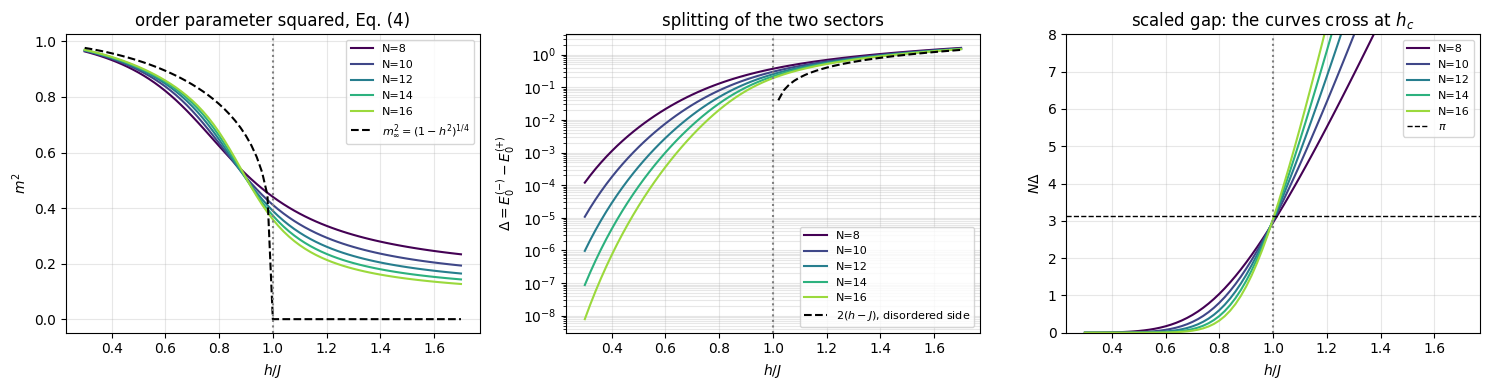

  N | m^2 at h=0.5 | N m^2 at h=1.5 | gap at h=0.5 | gap at h=1.5 | N * gap at h=1 | Eq. (5b) | S(N/2) at h=0.4
  8 |       0.8880 |         2.0830 |     5.86e-03 |       1.2315 |         2.9526 |   2.9526 |          0.9999
 10 |       0.8969 |         2.1788 |     1.46e-03 |       1.1672 |         2.9892 |   2.9892 |          1.0014
 12 |       0.9022 |         2.2460 |     3.66e-04 |       1.1266 |         3.0139 |   3.0139 |          1.0017
 14 |       0.9059 |         2.2951 |     9.16e-05 |       1.0991 |         3.0318 |   3.0318 |          1.0017
 16 |       0.9087 |         2.3324 |     2.29e-05 |       1.0797 |         3.0452 |   3.0452 |          1.0017
exact: m^2(0.5) = 0.9306, m^2(1.5) = 0, Delta_inf(1.5) = 1.0000, N*Delta -> pi = 3.1416 at h_c, S -> 1 bit (cat state)


In [7]:
# ------------------------------------------------------------------------------
# FIGURE: order parameter, sector splitting, and the scaled gap
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
cols = plt.cm.viridis(np.linspace(0.0, 0.85, len(NS)))
ax = axes[0]
for N, c in zip(NS, cols):
    ax.plot(HS, scan[N]["m2"], "-", color=c, label=f"N={N}")
ax.plot(HS, tfim_exact_magnetisation(HS) ** 2, "k--", lw=1.5, label=r"$m_\infty^2=(1-h^2)^{1/4}$")
ax.axvline(1.0, color="gray", ls=":")
ax.set_xlabel("$h/J$"); ax.set_ylabel("$m^2$"); ax.set_title("order parameter squared, Eq. (4)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
for N, c in zip(NS, cols):
    ax.semilogy(HS, scan[N]["gap"], "-", color=c, label=f"N={N}")
ax.semilogy(HS[HS > 1], 2 * (HS[HS > 1] - 1.0), "k--", lw=1.5, label=r"$2(h-J)$, disordered side")
ax.axvline(1.0, color="gray", ls=":")
ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$\Delta=E_0^{(-)}-E_0^{(+)}$"); ax.set_title("splitting of the two sectors")
ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
ax = axes[2]
for N, c in zip(NS, cols):
    ax.plot(HS, N * scan[N]["gap"], "-", color=c, label=f"N={N}")
ax.axvline(1.0, color="gray", ls=":"); ax.axhline(np.pi, color="k", ls="--", lw=1, label=r"$\pi$")
ax.set_ylim(0, 8); ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$N\Delta$")
ax.set_title(r"scaled gap: the curves cross at $h_c$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

i_lo, i_hi, i_c = (int(np.argmin(abs(HS - x))) for x in (0.5, 1.5, 1.0))
print(f"{'N':>3} | {'m^2 at h=0.5':>12} | {'N m^2 at h=1.5':>14} | {'gap at h=0.5':>12} | {'gap at h=1.5':>12} | "
      f"{'N * gap at h=1':>14} | {'Eq. (5b)':>8} | {'S(N/2) at h=0.4':>15}")
for N in NS:
    print(f"{N:>3} | {scan[N]['m2'][i_lo]:12.4f} | {N * scan[N]['m2'][i_hi]:14.4f} | {scan[N]['gap'][i_lo]:12.2e} | "
          f"{scan[N]['gap'][i_hi]:12.4f} | {N * scan[N]['gap'][i_c]:14.4f} | {4 * N * np.sin(np.pi / (4 * N + 2)):8.4f} | "
          f"{scan[N]['S'][int(np.argmin(abs(HS - 0.4)))]:15.4f}")
print(f"exact: m^2(0.5) = {tfim_exact_magnetisation(0.5) ** 2:.4f}, m^2(1.5) = 0, Delta_inf(1.5) = {2 * 0.5:.4f}, "
      f"N*Delta -> pi = {np.pi:.4f} at h_c, S -> 1 bit (cat state)")

**Interpretation.**

- *Left*: $m^2$ is a smooth curve for every $N$. It does not jump; it does not vanish above $h_c$ (it decays as
  $1/N$ there: by Eq. (4), $Nm^2=\sum_r\langle Z_0Z_r\rangle$ summed over a finite correlation length, which the
  table shows still rising slowly at $h=1.5$, from $2.08$ to $2.33$; $N$ uncorrelated spins would give exactly $1$); and below $h_c$ it sits **under** the
  exact $m_\infty^2$, because a finite chain cannot order completely. A transition is visible only as a steepening
  with $N$ - which is exactly what finite-size scaling will exploit in Sec. 8. The curves cross near $h\approx0.87$
  and not at $h_c$: at $h_c$ itself $m^2$ falls as $N^{-2\beta/\nu}$, so only the rescaled $m^2N^{2\beta/\nu}$ of
  Sec. 8 has $N$-independent values there.
- *Centre* (logarithmic scale): the splitting of the two parity sectors behaves completely differently on the two
  sides. Above $h_c$ it converges to the bulk gap $2(h-J)$ and is finite. Below $h_c$ it collapses **exponentially
  with $N$** - at $h=0.5$ it falls from $6\times10^{-3}$ at $N=8$ to $2\times10^{-5}$ at $N=16$ - because there it
  measures the **tunnelling splitting** between the two ferromagnets, the quantity derived in notebook 11
  (Chapter 5); for $h=0.5$ its formula $1.5J\cdot2^{-N}$ gives $5.9\times10^{-3}$ and
  $2.3\times10^{-5}$. The *physical* excitation gap $2(J-h)$ of the ordered phase lies above that doublet.
- *Right*: multiply the splitting by $N$. Below $h_c$ the exponential wins and $N\Delta\to0$; above $h_c$ the gap is
  finite and $N\Delta\to\infty$; exactly at $h_c$ the gap is $\propto1/N$ and $N\Delta$ is **almost independent of
  $N$** - this is the dynamical exponent $z=1$. The table shows $N\Delta$ rising from $2.95$ at $N=8$ to $3.05$ at
  $N=16$, exactly as Eq. (5b) predicts, towards the limit $\pi$. Curves for different $N$ therefore **cross** close
  to the critical point, which is the cleanest locator in this notebook (Sec. 8); the residual $1/N$ drift of
  $N\Delta$ is what moves the crossings slightly below $h_c$.

## 6. Signature 3: entanglement entropy and the central charge

The entropy of a block is rarely measured directly in experiments; numerically it is the sharpest signature of
criticality, and it carries a number that identifies the *universality class*.

Away from the critical point the ground state of a gapped local Hamiltonian obeys an **area law**: in one dimension
the entropy of a block saturates at a constant of order $\ln\xi$, with $\xi$ the correlation length, independent of
the block size. That is the statement that made the matrix product states of the previous chapters work at all.

There is a trap on the ordered side. The parity-even ground state of a finite chain is not a ferromagnet; by
Eq. (3) it is the **cat state** $(\vert\!\uparrow\cdots\uparrow\rangle+\vert\!\downarrow\cdots\downarrow\rangle)/\sqrt2$, up to
corrections. Every cut of that state has exactly two Schmidt values $1/\sqrt2$, so it carries **exactly one bit**,
whatever $N$ and wherever the cut. Deep in the ordered phase the measured half-chain entropy is therefore
$1.00$ bits for every chain length (the table of Sec. 5 gives $0.9999$-$1.0017$ at $h=0.4$), and that plateau is not
criticality: it is the classical correlation between two macroscopically distinct configurations. It is also
*larger* than the critical value ($0.61$ bits at $N=16$, $h=h_c$, table below), so the maximum of $S(N/2)$ as a
function of $h$ lies inside the ordered phase for these chain lengths. This is why the entropy is a poor *locator*
of this transition. It remains an excellent *identifier* of the critical theory, which is what the rest of this
section uses it for.

At the critical point $\xi$ diverges and the area law fails: the entropy grows with the size of the block,
logarithmically. For an **open** chain of $N$ sites cut after $\ell$ sites the precise form is (Calabrese and
Cardy 2004)

$$ S(\ell,N)=\frac{c}{6}\,\ln\Big[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\Big]+\text{const} , \qquad (8) $$

The only thing we do with this formula is **fit** it: plot the measured $S$ against the logarithm of the bracket
and read off the slope, which is $c/6$ for $S$ in nats and $c/(6\ln2)$ for $S$ in bits. What makes that worth doing is that $c$ comes out the same for *every*
model with the same kind of critical point - $1/2$ for the Ising transition, $1$ for the XX and XXZ critical line
of Sec. 10 - and different for different kinds. It is a fingerprint, and that is all we use it for.

> **What you need and what you do not.** The fitted number is called the **central charge**, and it comes from the
> field theory of critical points, which this course does not develop. Nothing here requires knowing where it
> comes from: compute the profile, fit the slope, compare the label with the known value. A finite chain does not
> possess a central charge; the fit returns an *effective* $c_{\rm eff}(N)$ that drifts towards $c$ as $N$ grows.

The prefactor is $c/6$ for open boundaries and $c/3$ for a block of a periodic chain: the block of a ring has two
boundary points with the rest of the system, the left part of an open chain only one, and each boundary point
contributes $\frac c6\ln(\cdot)$.

Two cautions come with Eq. (8). The formula is asymptotic, so short blocks and small chains carry corrections that
decay only slowly with $N$. And in some open chains - the XX and XXZ chains of Sec. 10 - the corrections
**alternate** with the parity of $\ell$, which is why `central_charge_fit` can restrict the fit to even cuts. The
Ising profile turns out to be smooth: the table below shows the all-cut and even-cut fits agreeing to about $0.002$.

In [8]:
# ==============================================================================
# STEP 4: entropy profile of a state, and the central charge fitted from Eq. (8)
# ==============================================================================
def entropy_profile(psi, N):
    """Entanglement entropy (bits) of every cut 1..N-1 of an N-spin state."""
    return np.array([float(entanglement_entropy(psi, range(l))) for l in range(1, N)])


def central_charge_fit(S_profile, N, skip=1, even_only=False):
    """Central charge from the Calabrese-Cardy law (8): linear fit of S against ln[(2N/pi) sin(pi l / N)].

    The slope is c/6 in BITS per unit of ln, i.e. c = 6 * slope * ln 2 in the natural (nats) normalisation used
    by conformal field theory.  `skip` drops the `skip` cuts nearest each end, where the asymptotic form is worst."""
    l = np.arange(1, N)
    x = np.log((2 * N / np.pi) * np.sin(np.pi * l / N))
    keep = np.ones_like(l, dtype=bool)
    keep[:skip] = keep[len(keep) - skip:] = False
    if even_only:
        keep &= (l % 2 == 0)
    slope, const = np.polyfit(x[keep], S_profile[keep], 1)
    return 6.0 * slope * np.log(2.0), const


# ------------------------------------------------------------------------------
# EXPERIMENT: the entropy profile at the critical point, and the central charge
# ------------------------------------------------------------------------------
i_crit = int(np.argmin(abs(HS - 1.0)))
prof = {N: entropy_profile(scan[N]["states"][i_crit], N) for N in NS}
prof_off = {N: entropy_profile(scan[N]["states"][int(np.argmin(abs(HS - 1.6)))], N) for N in NS}
print(f"{'N':>3} | {'c (all cuts)':>12} | {'c (even cuts)':>13} | {'S(N/2) at h=1':>13} | {'S(N/2) at h=1.6':>15}")
for N in NS:
    c_all, _ = central_charge_fit(prof[N], N)
    c_even, _ = central_charge_fit(prof[N], N, even_only=True)
    print(f"{N:>3} | {c_all:12.4f} | {c_even:13.4f} | {prof[N][N // 2 - 1]:13.4f} | {prof_off[N][N // 2 - 1]:15.4f}")
slope_N = np.polyfit(np.log(np.array(NS)), [prof[N][N // 2 - 1] for N in NS], 1)[0]
print(f"\nS(N/2) against ln N at h=1: slope = {slope_N:.4f} bits  ->  c = 6 * slope * ln2 = {6 * slope_N * np.log(2):.4f}   (exact 0.5)")
print(f"S(N/2) at h=1.6 grows by only {prof_off[16][7] - prof_off[8][3]:.3f} bits from N=8 to N=16 (area law: it saturates)")
assert 0.4 < 6 * slope_N * np.log(2) < 0.65

  N | c (all cuts) | c (even cuts) | S(N/2) at h=1 | S(N/2) at h=1.6
  8 |       0.5728 |        0.5718 |        0.5153 |          0.1941
 10 |       0.5687 |        0.5691 |        0.5469 |          0.1946
 12 |       0.5649 |        0.5662 |        0.5721 |          0.1948
 14 |       0.5616 |        0.5634 |        0.5930 |          0.1948
 16 |       0.5587 |        0.5608 |        0.6109 |          0.1948

S(N/2) against ln N at h=1: slope = 0.1379 bits  ->  c = 6 * slope * ln2 = 0.5734   (exact 0.5)
S(N/2) at h=1.6 grows by only 0.001 bits from N=8 to N=16 (area law: it saturates)


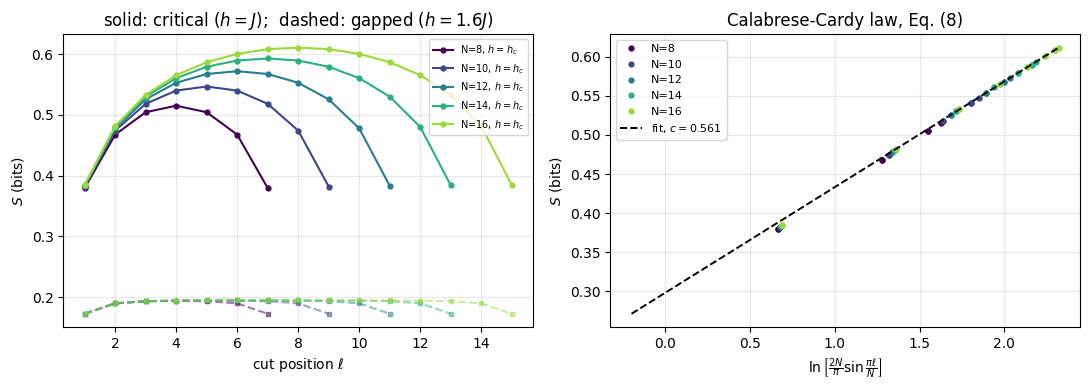

In [9]:
# ------------------------------------------------------------------------------
# FIGURE: entropy profiles and the Calabrese-Cardy fit
# ------------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
for N, c in zip(NS, cols):
    ax.plot(np.arange(1, N), prof[N], "o-", ms=3.5, color=c, label=f"N={N}, $h=h_c$")
    ax.plot(np.arange(1, N), prof_off[N], "s--", ms=3, color=c, alpha=0.5)
ax.set_xlabel("cut position $\\ell$"); ax.set_ylabel("$S$ (bits)")
ax.set_title("solid: critical ($h=J$);  dashed: gapped ($h=1.6J$)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[1]
for N, c in zip(NS, cols):
    l = np.arange(1, N)
    x = np.log((2 * N / np.pi) * np.sin(np.pi * l / N))
    ax.plot(x, prof[N], "o", ms=3.5, color=c, label=f"N={N}")
c_fit, const_fit = central_charge_fit(prof[16], 16, even_only=True)
xg = np.linspace(-0.2, np.log(2 * 16 / np.pi), 50)
ax.plot(xg, (c_fit / 6 / np.log(2)) * xg + const_fit, "k--", lw=1.4, label=rf"fit, $c={c_fit:.3f}$")
ax.set_xlabel(r"$\ln\left[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\right]$"); ax.set_ylabel("$S$ (bits)")
ax.set_title("Calabrese-Cardy law, Eq. (8)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** At the critical point the profile is a smooth arch that grows with $N$ and falls close to a
straight line when plotted against the conformal coordinate of Eq. (8). The fitted slope gives $c_{\rm eff}=0.573$
at $N=8$ and $0.559$ at $N=16$ (the even-cut fit drawn in the figure gives $0.561$), and the half-chain entropy
against $\ln N$ gives $0.573$: $12$ to $15\,\%$ above the Ising value $1/2$, drifting down slowly with $N$. That is enough to tell the Ising class from the $c=1$ class
of Sec. 10, but it is not a measurement of $c$ to better than ten per cent; Sec. 9 repeats the fit at $N=128$. In
the gapped phase the same profile is nearly flat and does not grow with $N$ at all: the area law. All-cut and
even-cut fits agree to about $0.002$, so the Ising profile carries no alternating correction worth removing.

> **Physics insight.** The central charge counts the massless degrees of freedom of the critical theory, and the
> entropy measures it without any knowledge of what the order parameter is. It therefore complements the
> classification by broken symmetry: it labels the conformal field theory that describes the critical point.

## 7. Signature 4: fidelity susceptibility - finding a transition without knowing the order parameter

All three signatures so far needed physical input: which operator orders, which symmetry sectors to use. The
fourth one needs none. Take the ground state at two nearby couplings and overlap them,

$$ F(h,\delta)=\big|\langle\psi_0(h)\vert\psi_0(h+\delta)\rangle\big| ,\qquad
   \chi_F(h)=\lim_{\delta\to0}\frac{2\big(1-F(h,\delta)\big)}{\delta^2} . \qquad (9) $$

The ground state changes slowly inside a phase and quickly where the state reorganises, so $\chi_F$ peaks at the
transition. First-order perturbation theory for the state makes this quantitative. With $H(h+\delta)=H(h)+\delta\,\partial_hH$
and $\partial_hH=-\sum_iX_i$ here,

$$ |\psi_0(h+\delta)\rangle=|\psi_0\rangle+\delta\sum_{n\neq0}\frac{\langle n|\partial_hH|\psi_0\rangle}{E_0-E_n}|n\rangle+\mathcal O(\delta^2)
   \quad\Longrightarrow\quad
   \chi_F=\sum_{n\neq0}\frac{\big|\langle n|\partial_hH|\psi_0\rangle\big|^2}{(E_n-E_0)^2} . \qquad (10) $$

The step to $\chi_F$ is the normalisation. With $c_n$ the coefficient of $|n\rangle$ in the first-order correction,
the normalised state has the overlap $F=\big(1+\delta^2\sum_{n\neq0}|c_n|^2\big)^{-1/2}\approx1-\frac{\delta^2}2\sum_{n\neq0}|c_n|^2$
with $|\psi_0\rangle$, and Eq. (9) gives $\chi_F=\sum_{n\neq0}|c_n|^2$. The sum in Eq. (10) is the squared length of the part of
$\partial_h|\psi_0\rangle$ orthogonal to $|\psi_0\rangle$, so by Eq. (71) of
[notebook 29](../ch10_quantum_metrology_protocols/29_quantum_fisher_information.ipynb) $\chi_F=F_Q/4$, a quarter of
the quantum Fisher information of the ground state for the parameter $h$.

The energy denominators explain the peak: $\chi_F$ blows up where the gap closes, provided the perturbation
actually connects the ground state to the low-lying states. It is **extensive** inside a phase, so the quantity to
compare across sizes is $\chi_F/N$, and at a critical point it acquires the anomalous scaling
$\chi_F/N\sim N^{2/\nu-1}$ (Campos Venuti and Zanardi 2007), which for the Ising chain ($\nu=1$) means $\chi_F/N\propto N$.

In practice Eq. (9) is evaluated with a finite $\delta$ - here the spacing of the scan grid - which is why the
grid was chosen fine. No excited states and no operators are needed: two ground states and one inner product.

In [10]:
# ==============================================================================
# STEP 5: fidelity susceptibility from neighbouring ground states of the scan
# ==============================================================================
def fidelity_susceptibility(states, hs):
    """chi_F at the midpoints of the grid, Eq. (9), from the overlaps of neighbouring ground states.
    Returns (midpoint fields, chi_F).  The phase of each Lanczos eigenvector is arbitrary, hence the modulus."""
    f = np.array([abs(complex(jnp.vdot(states[i], states[i + 1]))) for i in range(len(states) - 1)])
    d = np.diff(hs)
    return 0.5 * (hs[1:] + hs[:-1]), 2.0 * (1.0 - f) / d ** 2


chi = {N: fidelity_susceptibility(scan[N]["states"], HS) for N in NS}

# CHECKPOINT 4: the finite-difference chi_F against the sum over states, Eq. (10), from a dense diagonalisation
N_F, H_F = 10, 1.1
w_f, V_f = np.linalg.eigh(np.asarray(dense_hamiltonian(tfim_terms(N_F, 1.0, H_F), N_F)))
dH = np.asarray(dense_hamiltonian(heisenberg_terms(N_F, 0.0, 0.0, 0.0, hx=-1.0), N_F))        # dH/dh = -sum_i X_i
v0 = V_f[:, 0]
num = V_f[:, 1:].T @ (dH @ v0)
chi_exact = float(np.sum(np.abs(num) ** 2 / (w_f[1:] - w_f[0]) ** 2))
mv_f = make_tfim_matvec(N_F)
psis = [sector_ground_state(lambda p, _h=float(hh): mv_f(p, _h), N_F, +1, m=50, restarts=2)[1]
        for hh in (H_F - 0.01, H_F + 0.01)]
chi_fd = float(2 * (1 - abs(complex(jnp.vdot(psis[0], psis[1])))) / 0.02 ** 2)
print(f"chi_F at N={N_F}, h={H_F}:  finite difference {chi_fd:.6f}   sum over states, Eq. (10) {chi_exact:.6f}   "
      f"(relative difference {abs(chi_fd - chi_exact) / chi_exact:.1e})")
assert abs(chi_fd - chi_exact) / chi_exact < 1e-3

chi_F at N=10, h=1.1:  finite difference 0.960457   sum over states, Eq. (10) 0.960261   (relative difference 2.0e-04)


## 8. Finite-size scaling: from five smooth curves to a critical point and two exponents

Every quantity computed so far is analytic in $h$; the transition shows up only in how the curves *change with*
$N$. Finite-size scaling turns that into numbers. Near a continuous transition the correlation length is the only
relevant length, $\xi\sim|h-h_c|^{-\nu}$, and on a chain of $N$ sites a quantity $A$ with bulk behaviour
$A\sim|h-h_c|^{\kappa}$ obeys

$$ A(h,N)=N^{-\kappa/\nu}\,f_A\big((h-h_c)\,N^{1/\nu}\big) , \qquad (11) $$

with $f_A$ a universal function. Three consequences are used below.

1. **Pseudo-critical points.** Any feature (the peak of $\chi_F$, the peak of $S$, the minimum of the gap) sits at
   a size-dependent $h^*(N)=h_c+a\,N^{-1/\nu}$. Extrapolating $h^*(N)$ against $N^{-1/\nu}$ gives $h_c$ - and with
   $\nu=1$ that is a straight line in $1/N$.
2. **Peak heights.** $\chi_F^{\max}/N\sim N^{2/\nu-1}$, so a log-log plot of the peak height measures $\nu$
   without any knowledge of $h_c$. The same power holds at any fixed value of the scaling variable
   $(h-h_c)N^{1/\nu}$, in particular at $h=h_c$ itself, which can be used once $h_c$ is known.
3. **Data collapse.** Plotting $m^2N^{2\beta/\nu}$ against $(h-h_c)N^{1/\nu}$ must put all chain lengths on one
   curve if $h_c$, $\beta$ and $\nu$ are right. This is the most demanding test, because it uses the whole curve
   rather than one feature, and it is the one that fails visibly when the exponents are wrong.

The **crossings** of $N\Delta$ used in Sec. 5 obey a sharper law. Write $N\Delta=F(x)\,(1+b/N)$ with
$x=(h-h_c)N^{1/\nu}$ and a correction $b/N$ such as the one in Eq. (5b). Setting $N_1\Delta(N_1)=N_2\Delta(N_2)$ and
expanding $F$ to first order around $x=0$ gives, for $\nu=1$,

$$ F'(0)\,(h_\times-h_c)(N_1-N_2)=F(0)\,b\Big(\frac1{N_2}-\frac1{N_1}\Big)
   \quad\Longrightarrow\quad h_\times-h_c=\frac{F(0)\,b}{F'(0)}\,\frac{1}{N_1N_2} . \qquad (11b) $$

The crossing therefore converges as $1/(N_1N_2)\sim N^{-2}$, one power of $N$ faster than a single-size feature,
and it must be extrapolated in that variable; a straight line in $1/N$ would overshoot.

In [11]:
# ==============================================================================
# STEP 6: peak location by parabolic interpolation, and the scaling analysis
# ==============================================================================
def peak_position(x, y):
    """Position of the maximum of y(x) by a parabola through the largest point and its two neighbours.
    MATH  for y_{k-1}=a, y_k=b, y_{k+1}=c on a uniform grid of spacing dx the vertex of the parabola is at
          x_k + (dx/2) (a - c) / (a - 2b + c)   (removes most of the grid discretisation)."""
    k = int(np.argmax(y))
    if k == 0 or k == len(y) - 1:
        return float(x[k])
    a, b, c = y[k - 1], y[k], y[k + 1]
    dx = x[k + 1] - x[k]
    return float(x[k] + 0.5 * dx * (a - c) / (a - 2 * b + c))


def collapse_cost(beta, nu, hc=1.0, xmax=3.0):
    """Spread of the rescaled curves y = m^2 N^{2 beta/nu} against x = (h - hc) N^{1/nu}, Eq. (11).
    MATH  interpolate every N onto a common grid of x in [-xmax, xmax]; cost = mean_x Var_N(y) / mean_x Mean_N(y)^2.
          Zero for a perfect collapse."""
    xg = np.linspace(-xmax, xmax, 61)
    Y = np.array([np.interp(xg, (HS - hc) * N ** (1 / nu), scan[N]["m2"] * N ** (2 * beta / nu)) for N in NS])
    return float(np.mean(np.var(Y, axis=0)) / np.mean(np.mean(Y, axis=0)) ** 2)


def crossing(N1, N2, lo=0.8, hi=1.4, J=1.0):
    """Field where N1 Delta(N1,h) = N2 Delta(N2,h), by bisection on the exact open-chain gap of Sec. 2."""
    f = lambda h: N1 * tfim_exact_gap(N1, J, h) - N2 * tfim_exact_gap(N2, J, h)
    for _ in range(60):
        mid = 0.5 * (lo + hi)
        lo, hi = (mid, hi) if f(mid) * f(lo) > 0 else (lo, mid)
    return 0.5 * (lo + hi)


h_star_chi = np.array([peak_position(*chi[N]) for N in NS])
chi_max = np.array([np.max(chi[N][1]) for N in NS])
inv_N = 1.0 / np.array(NS, dtype=float)
pairs = [(8, 10), (10, 12), (12, 14), (14, 16), (16, 24), (24, 32), (32, 48), (48, 64), (64, 96)]
h_cross = np.array([crossing(a, b) for a, b in pairs])
x_cross = np.array([2.0 / (a + b) for a, b in pairs])               # plotting coordinate, ~ 1/N
y_cross = np.array([1.0 / (a * b) for a, b in pairs])               # extrapolation variable of Eq. (11b)

slope_hc, hc_fit = np.polyfit(inv_N, h_star_chi, 1)
hc_fit_quad = np.polyfit(inv_N, h_star_chi, 2)[-1]                  # with an N^-2 term: a systematic-error gauge
hc_cross = np.polyfit(y_cross[-4:], h_cross[-4:], 1)[1]             # correct variable, Eq. (11b)
hc_cross_lin = np.polyfit(x_cross[-4:], h_cross[-4:], 1)[1]         # wrong variable (1/N), for comparison
expo, _ = np.polyfit(np.log(NS), np.log(chi_max / np.array(NS)), 1)
local_expo = np.diff(np.log(chi_max / np.array(NS))) / np.diff(np.log(NS))
chi_hc = np.array([np.interp(1.0, *chi[N]) for N in NS])            # chi_F at h_c (mean of the midpoints 0.99, 1.01)
expo_hc, _ = np.polyfit(np.log(NS), np.log(chi_hc / np.array(NS)), 1)
local_expo_hc = np.diff(np.log(chi_hc / np.array(NS))) / np.diff(np.log(NS))
print(f"{'N':>3} | {'h* (chi_F peak)':>15} | {'(h*-1) N':>8} | {'chi_F^max / N':>13} | {'chi_F(h_c) / N':>14} | {'N x gap at h=1':>14}")
for i, N in enumerate(NS):
    print(f"{N:>3} | {h_star_chi[i]:15.4f} | {(h_star_chi[i] - 1) * N:8.2f} | {chi_max[i] / N:13.3f} | {chi_hc[i] / N:14.4f} | "
          f"{N * scan[N]['gap'][i_c]:14.4f}")
print("\ncrossings of N*Delta:  " + ", ".join(f"({a},{b}) {h:.4f}" for (a, b), h in zip(pairs, h_cross)))
print("  (1 - h_x) N1 N2     :  " + ", ".join(f"{(1 - h) * a * b:.2f}" for (a, b), h in zip(pairs, h_cross)) + "   (Eq. (11b): constant)")
print(f"extrapolated from the four largest pairs in 1/(N1 N2) : h_c = {hc_cross:.6f}   (exact 1)")
print(f"  the same four pairs extrapolated in 1/N (wrong law)  : h_c = {hc_cross_lin:.5f}   (overshoots)")
print(f"extrapolated chi_F peak, h* = h_c + a/N  : h_c = {hc_fit:.4f};  with an extra b/N^2 term: {hc_fit_quad:.4f}   (exact 1)")
print(f"peak height chi_F^max/N ~ N^{expo:.3f} over N=8..16  ->  nu = 2/(exponent+1) = {2 / (expo + 1):.3f}   (exact 1)")
print("  successive-size exponents: " + ", ".join(f"{e:.2f}" for e in local_expo) + "   (still drifting upwards)")
print(f"chi_F at h_c:      chi_F/N ~ N^{expo_hc:.3f}             ->  nu = 2/(exponent+1) = {2 / (expo_hc + 1):.3f}")
print("  successive-size exponents: " + ", ".join(f"{e:.2f}" for e in local_expo_hc) + "   (drifting down towards 1)")
print("\ndata collapse of m^2, cost of Eq. (11) with h_c = 1 (0 = perfect):")
for b_, n_, tag in ((0.125, 1.0, "exact exponents"), (0.25, 1.0, "beta doubled"), (0.0, 1.0, "no rescaling of m^2"),
                    (0.125, 0.7, "nu = 0.7"), (0.125, 1.4, "nu = 1.4")):
    print(f"  beta = {b_:5.3f}, nu = {n_:3.1f}  ({tag:20s}): {collapse_cost(b_, n_):.2e}")
assert abs(hc_cross - 1.0) < 1e-3 and abs(hc_fit - 1.0) < 0.05
assert collapse_cost(0.125, 1.0) < min(collapse_cost(0.25, 1.0), collapse_cost(0.125, 0.7), collapse_cost(0.125, 1.4))

  N | h* (chi_F peak) | (h*-1) N | chi_F^max / N | chi_F(h_c) / N | N x gap at h=1
  8 |          0.7189 |    -2.25 |         0.314 |         0.1295 |         2.9526
 10 |          0.7790 |    -2.21 |         0.353 |         0.1656 |         2.9892
 12 |          0.8189 |    -2.17 |         0.395 |         0.2016 |         3.0139
 14 |          0.8470 |    -2.14 |         0.440 |         0.2376 |         3.0318
 16 |          0.8678 |    -2.12 |         0.485 |         0.2735 |         3.0452

crossings of N*Delta:  (8,10) 0.9854, (10,12) 0.9902, (12,14) 0.9929, (14,16) 0.9947, (16,24) 0.9969, (24,32) 0.9984, (32,48) 0.9992, (48,64) 0.9996, (64,96) 0.9998
  (1 - h_x) N1 N2     :  1.17, 1.18, 1.19, 1.20, 1.21, 1.22, 1.22, 1.23, 1.23   (Eq. (11b): constant)
extrapolated from the four largest pairs in 1/(N1 N2) : h_c = 0.999997   (exact 1)
  the same four pairs extrapolated in 1/N (wrong law)  : h_c = 1.00063   (overshoots)
extrapolated chi_F peak, h* = h_c + a/N  : h_c = 1.0172;  with an

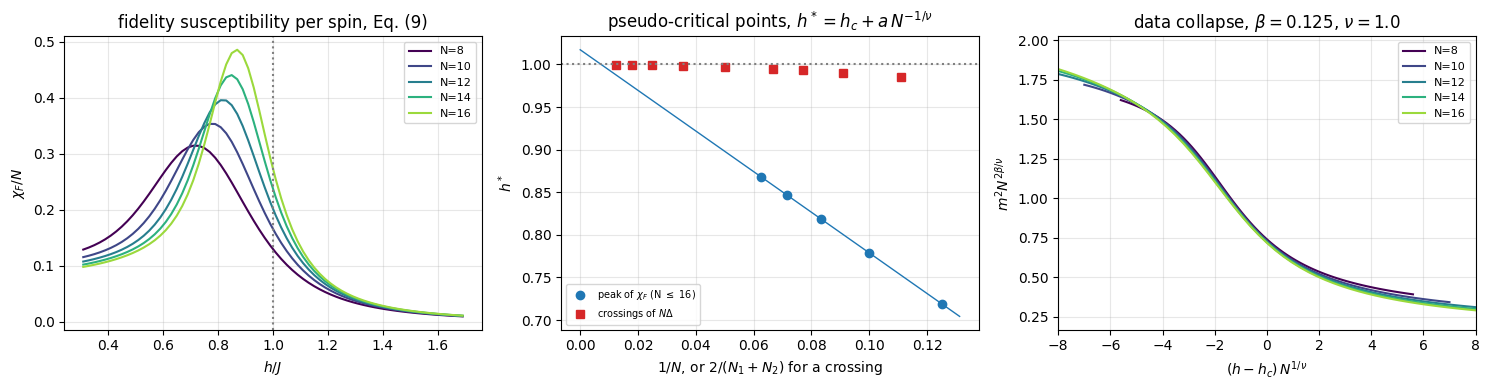

In [12]:
# ------------------------------------------------------------------------------
# FIGURE: fidelity susceptibility, extrapolation of the pseudo-critical points, and the data collapse
# ------------------------------------------------------------------------------
BETA, NU = 0.125, 1.0
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
ax = axes[0]
for N, c in zip(NS, cols):
    ax.plot(chi[N][0], chi[N][1] / N, "-", color=c, label=f"N={N}")
ax.axvline(1.0, color="gray", ls=":")
ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$\chi_F/N$"); ax.set_title("fidelity susceptibility per spin, Eq. (9)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(inv_N, h_star_chi, "o", color="C0", label=r"peak of $\chi_F$ (N $\leq$ 16)")
xg = np.linspace(0, 1.05 * inv_N.max(), 20)
ax.plot(xg, hc_fit + slope_hc * xg, "-", color="C0", lw=1)
ax.plot(x_cross, h_cross, "s", color="C3", label=r"crossings of $N\Delta$")
ax.axhline(1.0, color="gray", ls=":")
ax.set_xlabel(r"$1/N$, or $2/(N_1+N_2)$ for a crossing"); ax.set_ylabel("$h^*$")
ax.set_title(r"pseudo-critical points, $h^*=h_c+a\,N^{-1/\nu}$"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[2]
for N, c in zip(NS, cols):
    ax.plot((HS - 1.0) * N ** (1 / NU), scan[N]["m2"] * N ** (2 * BETA / NU), "-", color=c, label=f"N={N}")
ax.set_xlim(-8, 8)
ax.set_xlabel(r"$(h-h_c)\,N^{1/\nu}$"); ax.set_ylabel(r"$m^2N^{2\beta/\nu}$")
ax.set_title(rf"data collapse, $\beta={BETA}$, $\nu={NU}$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.**

- *Left*: $\chi_F/N$ has a peak that grows with $N$ and drifts towards $h_c$ **from below**. No order parameter,
  no symmetry sector and no excited state were used to produce it - only ground states and one inner product.
  The column $(h^*-1)N$ of the table is close to $-2$ for every $N$: the peak sits at a fixed value of the scaling
  variable, as Eq. (11) predicts, and well inside the scaling window.
- *Centre*: both locators extrapolate to the exact $h_c=1$, but not equally well. At equal sizes the crossing is
  far closer: $0.9947$ for the pair $(14,16)$ against $0.868$ for the $\chi_F$ peak at $N=16$. The printed
  $(1-h_\times)N_1N_2$ is constant to within a few per cent from $(8,10)$ to $(64,96)$, which confirms the
  $1/(N_1N_2)$ law of Eq. (11b); extrapolated in that variable the four largest pairs give $h_c$ to $3\times10^{-6}$,
  while the same four points extrapolated linearly in $1/N$ overshoot to $1.0006$ - further from $h_c$ than the
  last crossing itself. The $\chi_F$ peaks, which here use only $N\le16$, extrapolate to $1.017$ with a straight
  line in $1/N$ and to $1.011$ with an added $N^{-2}$ term; the difference between the two fits measures the
  systematic error, about one per cent.
- *Right*: with the exact exponents the five $m^2$ curves collapse onto one. The collapse cost printed above
  quantifies it: doubling $\beta$ or not rescaling $m^2$ at all makes the spread 13 and 30 times larger. The cost
  is much less sensitive to $\nu$ ($\nu=0.7$ costs only $25\,\%$ more than $\nu=1$), because over
  $N=8\ldots16$ the scaling variable $N^{1/\nu}$ changes by a factor of only $2^{1/\nu}$: a collapse at these
  sizes tests $\beta/\nu$ well and $\nu$ poorly.

> **Numerical practice.** Not every scaling law is equally usable at small sizes. The crossing of $N\Delta$,
> extrapolated with the right law, gives $h_c$ to $3\times10^{-6}$; the peak *positions* give it to a per cent; the peak
> *height* exponent, which should be $2/\nu-1=1$, comes out at $0.63$ over $N=8\ldots16$, and the successive-size
> exponents still drift upwards. The peak is inside the scaling window, so the window is not the problem. The
> problem is the non-singular part of $\chi_F$: Eq. (10) contains an extensive contribution from all excitations,
> so approximately $\chi_F^{\max}/N=aN+b$ with a positive constant $b$ that is not small at these sizes, and the
> local log-log slope $aN/(aN+b)$ stays below one. At fixed $h=h_c$ the corrections happen to be smaller and of the
> opposite sign: the same data give an exponent of $1.08$ ($\nu=0.96$), with successive-size values that approach
> $1$ from above. Quote an exponent only once
> the local exponents have stopped moving, and compare more than one estimator before trusting any of them.

## 9. Beyond exact diagonalisation: the same analysis with DMRG

Sixteen spins were enough to see every signature and to get $h_c$ to a per cent, but the scaling analysis rested
on five points, the smallest of which is arguably too small to be in the scaling regime at all. Notebook 18
(Chapter 7) built a method that removes that restriction: **DMRG** finds the ground state of a chain of a hundred
spins directly in the matrix product format. The critical ground state is the *worst* case for an MPS, which makes
this a stringent test of the method: by Eq. (8) the entropy of the central cut grows by $\frac c6\log_22=1/12$
bit per doubling of $N$ instead of saturating, so the number of Schmidt values that matter, and with it the bond
dimension needed for a fixed accuracy, keeps growing with $N$ - slowly, but without bound.

> **Common pitfall.** A number that looks plausible is not yet a ground-state energy. The Néel product state has the
> *positive* energy $+(N-1)J$ for this ferromagnetic model, so every local problem of the first steps has a positive
> spectrum - and a solver with a spurious zero eigenvalue then returns $E=0$ exactly. This happens when the bond
> bases contain zero-norm directions (notebook 18, Sec. 6.6): the state collapses to the zero vector, and $E=0$ is
> printed for every sweep without an error. The engine's `dmrg` therefore builds its bond bases from genuine
> block states only and raises an error if a local step or the final state loses its norm; from the Néel start, the
> all-up state and $|+\cdots+\rangle$ alike it reaches the exact energy at $N=24$ within two sweeps (to $2\times10^{-13}$,
> $1\times10^{-11}$ and $9\times10^{-14}$). The code below starts from $|+\cdots+\rangle$, the exact ground state for
> $h\to\infty$ and the closest of the three after one sweep. Whatever the start, check the converged energy against
> something independent - below, the exact free-fermion value.

The Hamiltonian enters as the matrix product operator of notebook 18, Sec. 6.2, which already covers the TFIM:
`xxz_mpo(N, 0, 0, -J, hx=-h)` builds $-J\sum Z_iZ_{i+1}-h\sum X_i$ as a $D=5$ machine, two of whose states (the
$X$ and $Y$ channels) are never used here - a $D=3$ machine suffices, Exercise 6. The measurements are the MPS
routines of the same notebook: `mps_entropies` for every cut at once, and `mps_correlator` for
$\langle Z_iZ_j\rangle$.

### 9.1 The order parameter at large $N$

Summing $\langle Z_iZ_j\rangle$ over all pairs, as in Eq. (4), costs $\mathcal O(N^2)$ correlators. The standard
substitute uses the *long-distance* value of the correlation function from a reference site in the bulk,

$$ m^2_{\rm bulk}(N)=\big\langle Z_{N/4}\,Z_{3N/4}\big\rangle , \qquad (12) $$

which has the same scaling with $N$ and costs $\mathcal O(N)$ contractions. Below the transition it tends to
$m_\infty^2$; above it, it decays exponentially; at $h_c$ it decays as a power, $\langle Z_0Z_r\rangle\sim r^{-1/4}$,
which is the exponent $\eta=1/4$ of the Ising universality class.

In [13]:
# ==============================================================================
# STEP 7: the TFIM as a matrix product operator, and its ground state by DMRG
# ==============================================================================
def tfim_mpo(N, J=1.0, h=1.0):
    """MPO of H = -J sum Z_i Z_{i+1} - h sum X_i, from the XXZ machine of notebook 18 (Chapter 7) with Jxx = Jyy = 0."""
    return xxz_mpo(N, 0.0, 0.0, -J, hx=-h)


def dmrg_ground_state(N, h, chi=32, n_sweeps=5, J=1.0):
    """DMRG ground state of the TFIM, started from |+...+>, the ground state of the field term alone.

    WHY THAT START  |+...+> is the sensible physical guess, being exact as h -> infinity; at N = 24 it is the closest
    of |+...+>, all-up and Neel after one sweep (all three converge to the exact energy within two sweeps).
    RETURNS  (energy, B, lam, largest discarded weight of the last sweep, energy at the end of every sweep)."""
    M0, _ = product_mps("+" * N, chi)
    B, lam, hist = dmrg(tfim_mpo(N, J, h), M0, chi, n_sweeps)
    eps = max(x[4] for x in hist if x[0] == n_sweeps - 1)
    E_sweeps = np.array([[x[3] for x in hist if x[0] == s][-1] for s in range(n_sweeps)])
    return hist[-1][3], B, lam, eps, E_sweeps


# ------------------------------------------------------------------------------
# CHECKPOINT 6: DMRG against exact diagonalisation (N=16) and against the exact energy at N=64
# ------------------------------------------------------------------------------
for h_ in (0.6, 1.0, 1.4):
    E_dmrg, B_16, lam_16, eps_16, _ = dmrg_ground_state(16, h_, chi=32, n_sweeps=5)
    i_h = int(np.argmin(abs(HS - h_)))
    E_ed = scan[16]["E0"][i_h]
    S_dmrg = float(mps_entropies(lam_16)[8])
    print(f"N=16, h={h_}:  E_DMRG = {E_dmrg:.10f} vs E_Lanczos = {E_ed:.10f} (difference {abs(E_dmrg - E_ed):.1e}), "
          f"S(N/2) = {S_dmrg:.6f} vs {scan[16]['S'][i_h]:.6f}, discarded weight {eps_16:.1e}")
    assert abs(E_dmrg - E_ed) < 1e-8 and abs(S_dmrg - scan[16]["S"][i_h]) < 1e-6

# the free-fermion formula is exact for ANY N: use it at N=64, where no state vector exists
for chi_ in (16, 32, 64):
    E64, _, _, eps64, _ = dmrg_ground_state(64, 1.0, chi=chi_, n_sweeps=5)
    E_exact_64 = -np.sum(np.linalg.svd(1.0 * np.eye(64) + 1.0 * np.eye(64, k=1), compute_uv=False))
    print(f"N=64 critical, chi={chi_:2d}: E = {E64:.10f}, exact {E_exact_64:.10f}, relative error "
          f"{abs(E64 - E_exact_64) / abs(E_exact_64):.1e}, discarded weight {eps64:.1e}")
assert abs(E64 - E_exact_64) / abs(E_exact_64) < 1e-8

N=16, h=0.6:  E_DMRG = -16.6654564171 vs E_Lanczos = -16.6654564171 (difference 2.1e-13), S(N/2) = 1.008346 vs 1.008346, discarded weight 2.2e-31


N=16, h=1.0:  E_DMRG = -20.0163879005 vs E_Lanczos = -20.0163879005 (difference 4.1e-13), S(N/2) = 0.610851 vs 0.610851, discarded weight 2.9e-22


N=16, h=1.4:  E_DMRG = -25.1622034887 vs E_Lanczos = -25.1622034887 (difference 1.1e-13), S(N/2) = 0.255292 vs 0.255292, discarded weight 3.4e-31


N=64 critical, chi=16: E = -81.1259800987, exact -81.1259801231, relative error 3.0e-10, discarded weight 1.4e-10


N=64 critical, chi=32: E = -81.1259801231, exact -81.1259801231, relative error 3.3e-14, discarded weight 1.8e-14


N=64 critical, chi=64: E = -81.1259801231, exact -81.1259801231, relative error 4.0e-15, discarded weight 1.7e-19


DMRG reproduces the Lanczos energies and entropies at $N=16$, and at $N=64$ - where the state vector would need
$10^{19}$ complex numbers - it reproduces the exact free-fermion energy, which for the open chain is
$E_0=-\sum_n s_n$ with $s_n$ the singular values of the bidiagonal matrix of Sec. 2. The error falls with $\chi$
and tracks the discarded weight, as in notebook 18 (Chapter 7). *At the critical point* the Schmidt spectrum
decays more slowly than in a gapped phase - at $N=16$ and $\chi=32$ the discarded weight is $3\times10^{-22}$ at
$h_c$ against $2\times10^{-31}$ and $3\times10^{-31}$ at $h=0.6$ and $1.4$ - which is the price of the
logarithmic entropy.

### 9.2 The scan at $N=32$, $64$ and $128$

Now the same field scan as in Sec. 4, but with chains that are no longer reachable by exact diagonalisation. The
grid is coarse, because each point is a full DMRG run: $2(N-1)=254$ local eigenvalue problems per sweep at
$N=128$. Three sweeps suffice: the energy of the critical $N=128$ run, printed after every sweep below, is within
$6\times10^{-10}$ of the exact value after the third (a relative error of $4\times10^{-12}$), and every energy of the scan is graded against the exact free-fermion values. Three
lengths, each twice the previous one, are used: a factor of two in $N$ is the unit in which $N^{-2\beta/\nu}$ and
$\tfrac c6\log_2N$ are read.

In [14]:
# ==============================================================================
# EXPERIMENT: DMRG scan of the transition for three large chains
# ==============================================================================
NS_D = (32, 64, 128)                                       # each length is twice the previous one
HS_D = np.round(np.arange(0.70, 1.3001, 0.10), 4)          # coarse: every point is a full DMRG run
CHI_D = 48
SWEEPS_D = 3
dscan = {}
for N in NS_D:
    t0 = time.perf_counter()
    m2b, Sc, eps_all, dE, z_mid = [], [], [], [], []
    for h in HS_D:
        E, B, lam, eps, E_sw = dmrg_ground_state(N, float(h), chi=CHI_D, n_sweeps=SWEEPS_D)
        E_exact = -np.sum(np.linalg.svd(float(h) * np.eye(N) + np.eye(N, k=1), compute_uv=False))
        # grade against the ground DOUBLET: any combination of the two parity states lies in [E0, E0 + gap/2]
        dE.append(max(E - E_exact - 0.5 * tfim_exact_gap(N, 1.0, float(h)), 0.0) / abs(E_exact))
        z_mid.append(float(mps_expect_sites(B, lam, Z)[N // 2]))
        m2b.append(float(mps_correlator(B, lam, Z, N // 4, Z, 3 * N // 4)))
        Sc.append(float(mps_entropies(lam)[N // 2]))
        eps_all.append(eps)
        if abs(h - 1.0) < 1e-9:                                 # keep the critical state: the figure below needs no new run
            crit = {"E_c": E, "E_sweeps": E_sw - E_exact, "prof": np.asarray(mps_entropies(lam))[1:N],
                    "corr": np.array([float(mps_correlator(B, lam, Z, N // 2 - r // 2, Z, N // 2 + r // 2))
                                      for r in range(2, N // 2 + 1, 2)])}
    dscan[N] = {"m2": np.array(m2b), "S": np.array(Sc), "eps": np.array(eps_all), "z_mid": np.array(z_mid), **crit}
    print(f"N={N:3d}: {len(HS_D)} fields in {time.perf_counter() - t0:5.1f} s | largest discarded weight {max(eps_all):.1e} | "
          f"largest energy excess above the doublet {max(dE):.1e} (relative) | S(N/2) at h=1: "
          f"{dscan[N]['S'][int(np.argmin(abs(HS_D - 1.0)))]:.4f} bits | at h=0.7: <Z_N/2> = {z_mid[0]:+.3f}, "
          f"S(N/2) = {Sc[0]:.3f} bits")
    assert max(dE) < 1e-10
print(f"critical N={NS_D[-1]} run, E - E_exact after each sweep: " + ", ".join(f"{e:.1e}" for e in dscan[NS_D[-1]]["E_sweeps"]))

N= 32: 7 fields in  41.2 s | largest discarded weight 3.0e-10 | largest energy excess above the doublet 0.0e+00 (relative) | S(N/2) at h=1: 0.7007 bits | at h=0.7: <Z_N/2> = +0.919, S(N/2) = 0.019 bits


N= 64: 7 fields in  80.7 s | largest discarded weight 9.4e-11 | largest energy excess above the doublet 0.0e+00 (relative) | S(N/2) at h=1: 0.7875 bits | at h=0.7: <Z_N/2> = +0.919, S(N/2) = 0.019 bits


N=128: 7 fields in 164.9 s | largest discarded weight 1.0e-11 | largest energy excess above the doublet 0.0e+00 (relative) | S(N/2) at h=1: 0.8725 bits | at h=0.7: <Z_N/2> = +0.919, S(N/2) = 0.019 bits
critical N=128 run, E - E_exact after each sweep: 2.5e-02, 9.5e-05, 5.7e-10


> **Common pitfall.** In the ordered phase DMRG does *not* return the parity-even cat state of Sec. 2.2. At
> $h=0.7$ the printed $\langle Z_{N/2}\rangle$ is about $0.92$ and the half-chain entropy is close to zero instead
> of one bit: the sweep has converged to a **symmetry-broken** combination of the two lowest states,
> $(|\psi_0\rangle\pm|\psi_1\rangle)/\sqrt2$, whose energy $E_0+\Delta/2$ exceeds the ground-state energy only by
> half the tunnelling splitting - $6\times10^{-6}$ at $N=32$, $6\times10^{-11}$ at $N=64$ - far below what the
> truncation and the local solver resolve. That is why the energy above is graded against the doublet
> $[E_0,E_0+\Delta/2]$, and why a plain comparison with $E_0$ would report a spurious error of $10^{-7}$ at $N=32$.
> Equation (3) is not violated: it holds for exact eigenstates, and this state is an eigenstate only up to
> $\Delta/2$. The bulk correlator of Eq. (12) is the same for both combinations up to exponentially small terms, so
> the order parameter below is unaffected; the entanglement entropy is not, and in the ordered phase it must be read
> with this in mind. For $N\to\infty$ the broken state is the physical one - this is spontaneous symmetry breaking
> seen from the numerical side.

N=128 critical: central charge from Eq. (8) = 0.5140   (exact 0.5)
N=128 critical: local exponent of <Z Z> at the shortest distances = 0.264  (exact eta = 1/4);
   it drifts upwards with r: 0.26, 0.28, 0.29, 0.31, 0.32, 0.33  -- the open chain is not a pure power law


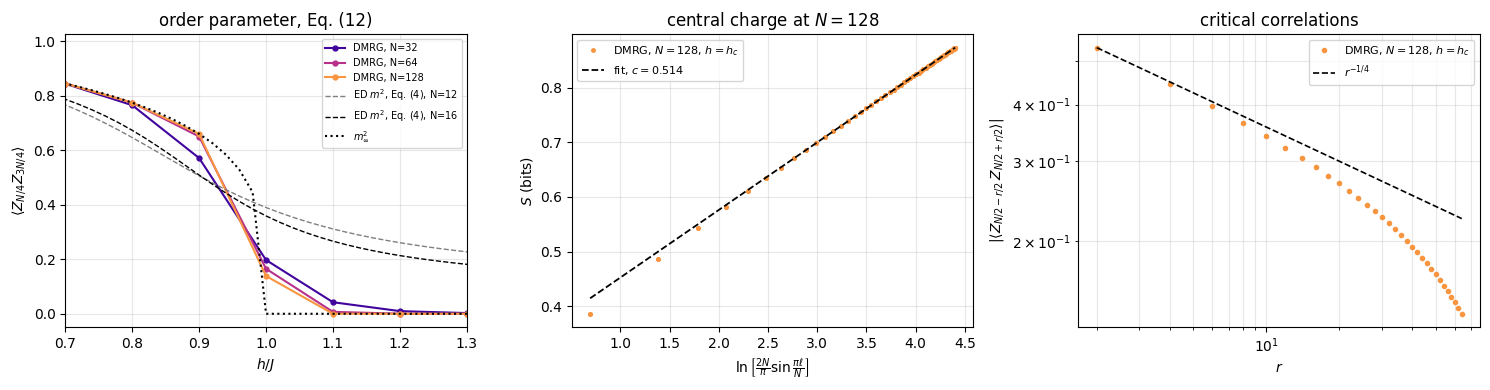

In [15]:
# ------------------------------------------------------------------------------
# FIGURE: DMRG scan, the critical entropy profile at the largest N, and the correlation function at h_c
# ------------------------------------------------------------------------------
N_C2 = NS_D[-1]                                                 # the largest chain of the scan, already solved at h_c
prof_c = dscan[N_C2]["prof"]
c_cft, const_c = central_charge_fit(prof_c, N_C2, skip=4, even_only=True)
rs_sym = np.arange(2, N_C2 // 2 + 1, 2)                         # centre-symmetric pairs: both sites far from the ends
corr_sym = dscan[N_C2]["corr"]
loc_eta = -np.diff(np.log(np.abs(corr_sym))) / np.diff(np.log(rs_sym))
eta_fit = loc_eta[0]
print(f"N={N_C2} critical: central charge from Eq. (8) = {c_cft:.4f}   (exact 0.5)")
print(f"N={N_C2} critical: local exponent of <Z Z> at the shortest distances = {eta_fit:.3f}  (exact eta = 1/4);")
print(f"   it drifts upwards with r: " + ", ".join(f"{e:.2f}" for e in loc_eta[:6]) + "  -- the open chain is not a pure power law")
assert abs(c_cft - 0.5) < 0.05 and abs(eta_fit - 0.25) < 0.05      # r << N: the pairs least affected by the open ends

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
cols_d = plt.cm.plasma(np.linspace(0.1, 0.75, len(NS_D)))
ax = axes[0]
for N, c in zip(NS_D, cols_d):
    ax.plot(HS_D, dscan[N]["m2"], "o-", ms=3.5, color=c, label=f"DMRG, N={N}")
for N, c in zip((12, 16), ("gray", "black")):
    ax.plot(HS, scan[N]["m2"], "--", lw=1, color=c, label=f"ED $m^2$, Eq. (4), N={N}")
ax.plot(HS, tfim_exact_magnetisation(HS) ** 2, "k:", lw=1.5, label=r"$m_\infty^2$")
ax.set_xlim(0.7, 1.3); ax.set_xlabel("$h/J$"); ax.set_ylabel(r"$\langle Z_{N/4}Z_{3N/4}\rangle$")
ax.set_title("order parameter, Eq. (12)"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax = axes[1]
l = np.arange(1, N_C2)
x_c = np.log((2 * N_C2 / np.pi) * np.sin(np.pi * l / N_C2))
ax.plot(x_c, prof_c, "o", ms=2.5, color=cols_d[-1], label=rf"DMRG, $N={N_C2}$, $h=h_c$")
xg = np.linspace(x_c.min(), x_c.max(), 20)
ax.plot(xg, (c_cft / 6 / np.log(2)) * xg + const_c, "k--", lw=1.3, label=rf"fit, $c={c_cft:.3f}$")
ax.set_xlabel(r"$\ln\left[\frac{2N}{\pi}\sin\frac{\pi\ell}{N}\right]$"); ax.set_ylabel("$S$ (bits)")
ax.set_title(rf"central charge at $N={N_C2}$"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[2]
ax.loglog(rs_sym, np.abs(corr_sym), "o", ms=3, color=cols_d[-1], label=rf"DMRG, $N={N_C2}$, $h=h_c$")
ax.loglog(rs_sym, np.abs(corr_sym)[0] * (rs_sym / rs_sym[0]) ** -0.25, "k--", lw=1.2, label=r"$r^{-1/4}$")
ax.set_xlabel("$r$"); ax.set_ylabel(r"$|\langle Z_{N/2-r/2}\,Z_{N/2+r/2}\rangle|$")
ax.set_title("critical correlations"); ax.legend(fontsize=8); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

**Interpretation.** The DMRG curves steepen with $N$: at $N=128$ the bulk correlator of Eq. (12) is already at
$m_\infty^2$ for $h=0.7$ and drops to $0.14$ at $h_c$ and to zero above, which is what the transition looks like as
$N$ grows. (The dashed ED curves show the all-pairs $m^2$ of Eq. (4), a different finite-size estimator of the same
quantity, which is why they lie below the DMRG points in the ordered phase and above them in the disordered one.) The central charge from the
$N=128$ profile is $c_{\rm eff}=0.514$, against $0.56$ at $N=16$: the excess over $1/2$ has dropped from $12\,\%$
to $3\,\%$ and is still a finite-size correction, as the slow drift at $N\le16$ suggested. The critical
correlations are a power law only for $r\ll N$: the local exponent is $0.26$ for the shortest centre-symmetric
pairs, close to $\eta=1/4$, and rises to $0.33$ by $r=14$ because the two sites approach the open ends, where the
correlations are suppressed. A sixteen-site chain has no range $1\ll r\ll N$ at all, which is why $\eta$ needs the
large chain (Exercise 3).

> **Numerical practice.** Every DMRG run here is monitored by its discarded weight and, because the TFIM is
> solvable, by its energy error. For a model without an exact solution only the first is available, together with
> the change of the results with $\chi$ and with the number of sweeps. The critical point is the hardest case for a
> given $\chi$ (Sec. 9.1), so when a scaling analysis is the goal, converge $\chi$ *at the critical point* and use
> that value everywhere.

## 10. A transition the same procedure cannot pin down

Everything so far worked because the Ising transition is a textbook continuous transition: a power-law divergent
correlation length, clean exponents, features that drift as $N^{-1/\nu}$. Not every transition is like that. The
XXZ chain

$$ H=\sum_i\big(X_iX_{i+1}+Y_iY_{i+1}+\Delta\,Z_iZ_{i+1}\big) \qquad (13) $$

is **critical for the whole range** $-1<\Delta\le1$ - a gapless line of critical points with central charge $c=1$ - and
gapped with Néel order for $\Delta>1$. The transition at $\Delta=1$ is of the **Kosterlitz-Thouless** type: the
gap opens with an essential singularity. The exact result of des Cloizeaux and Gaudin (1966), with
$\Delta=\cosh\Psi$, is $\Delta_{\rm gap}=(\pi J_S\sinh\Psi/\Psi)\sum_{n=-\infty}^{\infty}1/\cosh[(2n+1)\pi^2/(2\Psi)]$
for the spin-operator coupling $J_S$; in the Pauli convention of Eq. (13) $J_S=4$, and close to $\Delta=1$ the
$n=0,-1$ terms dominate (with $\Psi\approx\sqrt{2(\Delta-1)}$):

$$ \Delta_{\rm gap}\simeq16\pi\exp\Big(-\frac{\pi^2}{2\sqrt{2(\Delta-1)}}\Big) . \qquad (14) $$

No power of $\Delta-1$ behaves like this. The exact sum gives $\Delta_{\rm gap}=8\times10^{-6}$ at $\Delta=1.05$ and
$8\times10^{-4}$ at $\Delta=1.1$, against finite-size level spacings of order $1/N$; the correlation length,
which grows as the inverse gap, is far larger than any $N$ we can reach, so every chain in the neighbourhood of
$\Delta=1$ *looks* critical. Finite-size scaling does not fail loudly here - it fails quietly, by giving a smooth
curve with no feature to extrapolate.

The experiment below measures the same central charge as in Sec. 6, now as a function of $\Delta$, and asks where
the transition is. First a checkpoint: at $\Delta=0$ the model is the XX chain, free fermions again, so its exact
entropy profile is available for any $N$ and grades the DMRG result.

In [16]:
# ==============================================================================
# STEP 8: the XXZ chain -- free-fermion check at Delta = 0, then the central charge against Delta
# ==============================================================================
def xx_ground_entropy_profile(N, J=1.0):
    """Exact entanglement entropy (bits) of every cut of the XX-chain ground state at half filling.

    MATH  hopping matrix h1[i,i+1] = h1[i+1,i] = 2J;  occupy the N/2 lowest single-particle levels;
          C = sum_occ phi phi^T;  S(l) = -sum_m [nu log2 nu + (1-nu) log2(1-nu)], nu = eig(C[:l,:l])  (Peschel 2003).
    This is the ground-state twin of the time-dependent reference of notebook 18 (Chapter 7), Sec. 10.1."""
    h1 = 2.0 * J * (np.eye(N, k=1) + np.eye(N, k=-1))
    _, V = np.linalg.eigh(h1)
    C = V[:, : N // 2] @ V[:, : N // 2].T
    out = []
    for l in range(1, N):
        nu = np.clip(np.linalg.eigvalsh(C[:l, :l]), 1e-15, 1 - 1e-15)
        out.append(float(-np.sum(nu * np.log2(nu) + (1 - nu) * np.log2(1 - nu))))
    return np.array(out)


N_Z, CHI_Z = 32, 32
B_xx, lam_xx, _ = dmrg(xxz_mpo(N_Z, 1.0, 1.0, 0.0), product_mps(("01" * N_Z)[:N_Z], CHI_Z)[0], CHI_Z, 5)
prof_dmrg = np.asarray(mps_entropies(lam_xx))[1:N_Z]
prof_exact = xx_ground_entropy_profile(N_Z)
print(f"XX chain at N={N_Z}: max |S_DMRG - S_free-fermion| = {np.max(np.abs(prof_dmrg - prof_exact)):.1e}")
print(f"  central charge: DMRG {central_charge_fit(prof_dmrg, N_Z, skip=3, even_only=True)[0]:.4f}, "
      f"free fermions {central_charge_fit(prof_exact, N_Z, skip=3, even_only=True)[0]:.4f}   (exact 1)")
assert np.max(np.abs(prof_dmrg - prof_exact)) < 1e-4

XX chain at N=32: max |S_DMRG - S_free-fermion| = 1.7e-05
  central charge: DMRG 1.1174, free fermions 1.1175   (exact 1)


Delta = 0.00:  c_eff =  1.117 | S(N/2) = 1.2217 bits | staggered <Z Z> at r=N/2 = +0.0000 | E = -40.032775 | last-sweep dE 1e-12, discarded 8e-09


Delta = 0.50:  c_eff =  1.118 | S(N/2) = 1.0972 bits | staggered <Z Z> at r=N/2 = +0.0073 | E = -47.323707 | last-sweep dE 7e-12, discarded 7e-09


Delta = 1.00:  c_eff =  1.069 | S(N/2) = 1.0409 bits | staggered <Z Z> at r=N/2 = +0.0367 | E = -55.989261 | last-sweep dE 2e-12, discarded 1e-08


Delta = 1.05:  c_eff =  1.071 | S(N/2) = 1.0416 bits | staggered <Z Z> at r=N/2 = +0.0429 | E = -56.929100 | last-sweep dE 2e-12, discarded 1e-08


Delta = 1.50:  c_eff =  1.218 | S(N/2) = 1.1267 bits | staggered <Z Z> at r=N/2 = +0.1627 | E = -66.002399 | last-sweep dE 9e-13, discarded 1e-08


Delta = 2.00:  c_eff =  1.330 | S(N/2) = 1.2832 bits | staggered <Z Z> at r=N/2 = +0.4550 | E = -77.441211 | last-sweep dE 1e-13, discarded 2e-09
(6 DMRG runs at N=32, chi=32 in 33 s)


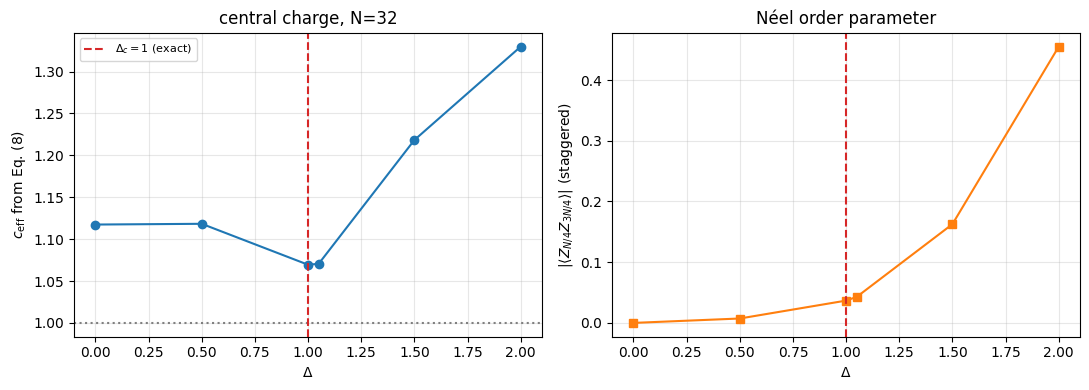

In [17]:
# ==============================================================================
# EXPERIMENT: central charge and staggered correlations across the Kosterlitz-Thouless point
# ==============================================================================
DELTAS = (0.0, 0.5, 1.0, 1.05, 1.5, 2.0)
kt = {}
t0 = time.perf_counter()
for D in DELTAS:
    B_d, lam_d, hist_d = dmrg(xxz_mpo(N_Z, 1.0, 1.0, D), product_mps(("01" * N_Z)[:N_Z], CHI_Z)[0], CHI_Z, 5)
    prof_d = np.asarray(mps_entropies(lam_d))[1:N_Z]
    c_eff, _ = central_charge_fit(prof_d, N_Z, skip=3, even_only=True)
    cst = (-1) ** (N_Z // 2) * float(mps_correlator(B_d, lam_d, Z, N_Z // 4, Z, 3 * N_Z // 4))
    kt[D] = {"c": c_eff, "S_mid": prof_d[N_Z // 2 - 1], "cst": cst, "E": hist_d[-1][3]}
    eps_d = max(x[4] for x in hist_d if x[0] == 4)                      # discarded weight, last sweep
    dE_d = abs(hist_d[-1][3] - [x[3] for x in hist_d if x[0] == 3][-1])  # energy change in the last sweep
    print(f"Delta = {D:4.2f}:  c_eff = {c_eff:6.3f} | S(N/2) = {prof_d[N_Z // 2 - 1]:.4f} bits | "
          f"staggered <Z Z> at r=N/2 = {cst:+.4f} | E = {hist_d[-1][3]:.6f} | last-sweep dE {dE_d:.0e}, "
          f"discarded {eps_d:.0e}")
print(f"({len(DELTAS)} DMRG runs at N={N_Z}, chi={CHI_Z} in {time.perf_counter() - t0:.0f} s)")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))
ax = axes[0]
ax.plot(DELTAS, [kt[D]["c"] for D in DELTAS], "o-", color="C0")
ax.axhline(1.0, color="gray", ls=":"); ax.axvline(1.0, color="C3", ls="--", label=r"$\Delta_c=1$ (exact)")
ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$c_{\rm eff}$ from Eq. (8)")
ax.set_title(f"central charge, N={N_Z}"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax = axes[1]
ax.plot(DELTAS, [abs(kt[D]["cst"]) for D in DELTAS], "s-", color="C1")
ax.axvline(1.0, color="C3", ls="--")
ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$|\langle Z_{N/4}Z_{3N/4}\rangle|$ (staggered)")
ax.set_title("Néel order parameter"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Interpretation.** The critical phase is identified: $c_{\rm eff}=1.07$-$1.12$ for $\Delta\le1$, close to the
free-boson value $c=1$ and clearly distinct from the $c=1/2$ of the Ising chain. The excess over one is a
finite-size correction of Eq. (8); DMRG adds nothing to it, since the exact free-fermion profile at $\Delta=0$ gives the same
$1.117$ at this $N$. Across $\Delta=1$ nothing happens. $c_{\rm eff}$ is $1.069$ at $\Delta=1$ and $1.071$ at
$\Delta=1.05$; it departs only somewhere between $\Delta=1.05$ and $1.5$, and then it *rises* ($1.22$, $1.33$)
rather than dropping towards zero as for a gapped chain. Eq. (8) has no meaning for a gapped state, and the fit
still returns a number: at $N=32$ the entropy profile of the Néel phase has not saturated (the half-chain entropy
grows from $1.04$ to $1.28$ bits between $\Delta=1$ and $2$). The staggered correlator rises smoothly through
$\Delta=1$ ($0.037$, $0.043$, $0.163$, $0.455$) without any feature either. There is no peak to locate, no crossing,
nothing to extrapolate: on these data alone the transition could be anywhere between $\Delta\approx1$ and
$\Delta\approx1.5$.

The reason is Eq. (14). Just above $\Delta=1$ the gap is tiny - $8\times10^{-6}$ at $\Delta=1.05$, five orders of
magnitude below the finite-size spacing of a 32-site chain - so a chain of 32, or 320, or 3200 spins is still
*inside* the correlation length and looks critical. The finite-size scaling of Sec. 8 assumed $\xi\sim|h-h_c|^{-\nu}$, a power law; an essential singularity
breaks that assumption, and the correct conclusion from these runs is "the transition is somewhere near
$\Delta\approx1$, and this method cannot do better". Locating a KT point needs either the dedicated logarithmic
corrections known for this class, or a completely different observable (the spin stiffness, or level spectroscopy
of excited states).

> **Caution.** A scaling analysis that produces a number always produces a number. The question is whether the
> model satisfies the assumption behind the analysis. The Ising and XXZ cases in this notebook are the same code
> and the same procedure, applied to a transition that fits the assumption and to one that does not.

## 11. Cost, and what limits the analysis

* **Exact diagonalisation** gives *everything* - all four signatures, exact gaps, arbitrary observables - for
  $N\le18$ or so, at $\mathcal O(2^N)$ memory. The scan of Sec. 4 was 71 fields $\times$ 5 lengths $\times$ 2 sectors
  $=710$ ground states, about two minutes on one core (printed above), most of it for $N=16$; continuation in $h$
  cuts that cost by more than half. Symmetry sectors are what make excited states cheap.
* **DMRG** reaches $N=100$ and more at $\mathcal O(N\chi^3)$ per sweep, but only for ground states, only for
  quantities expressible through the MPS, and with a bond dimension that must be converged *at the critical
  point*, where the entropy grows logarithmically. It brought $c$ to within $3\,\%$, made the exponent $\eta=1/4$
  visible at short distances, and extended the order parameter to $N=128$.
* **Free fermions** serve here as a *grader* rather than a method: whenever the model happens to be quadratic,
  $\mathcal O(N^3)$ linear algebra gives the exact answer for any $N$ and checks everything else. Use them wherever
  they exist; they do not generalise to interacting models.
* **What limits the result** is the *range of $N$*; the eigensolver contributes nothing, since the gaps agreed with
  the exact formula to $10^{-12}$. Exponents come from how quantities change with $N$, so the accuracy of $\nu$ is set by the
  ratio of the largest to the smallest chain and by how far the smallest one is from the scaling regime.
  Corrections to scaling entered twice: as the $N^{-2}$ term of the $\chi_F$-peak extrapolation, used to gauge its
  systematic error, and as the $1/N$ correction of Eq. (5b) behind the $1/(N_1N_2)$ law of the crossings. A
  precision study models them explicitly in every fit.

## 12. Key takeaways

* A quantum phase transition is a property of the **infinite chain**; every finite chain is analytic, gapped
  and symmetric. The numerical task is to extract the limit from a sequence of finite systems.
* The order parameter of a finite chain vanishes identically by symmetry, Eq. (3). Use $m^2$, or a long-distance
  correlator, and never a single $\langle Z_j\rangle$.
* A symmetry turns a ground-state solver into an excited-state solver: Lanczos inside a parity sector gives the
  gap as a difference of two ground-state energies.
* Four independent signatures locate the same transition: the order parameter, the gap ($\Delta\simeq\pi v/(2N)$
  at criticality on an open chain, $z=1$), the entanglement entropy (area law off criticality, $S=\frac{c}{6}\ln[\cdots]$ at it), and
  the fidelity susceptibility, which needs no order parameter and no symmetry - only two ground states and an
  overlap.
* The **central charge** read from the entropy identifies the critical theory: $c=1/2$ for the Ising chain,
  $c=1$ for the XX/XXZ critical line.
* **Finite-size scaling** converts drifting features into $h_c$ and the exponents: pseudo-critical points
  extrapolate as $N^{-1/\nu}$, crossings of $N\Delta$ as $1/(N_1N_2)$, peak heights scale with known powers but
  carry large non-singular corrections at small $N$, and a data collapse tests $\beta/\nu$ well and $\nu$ poorly.
* DMRG extends the same analysis to 128 spins, which brings $c$ to within 3 per cent and makes $\eta$ visible; at a critical
  point the bond dimension must be converged, because the entropy no longer saturates.
* The procedure has an assumption - a power-law correlation length - and a Kosterlitz-Thouless transition
  violates it. Then the analysis returns a smooth curve and no transition point, and saying so is the correct
  scientific answer.

## 13. Exercises

1. ★ **The gap exponent.** From the scan of Sec. 4, fit $\log\Delta(N,h_c)$ against $\log N$ and confirm $z=1$;
   compare the prefactor with Eq. (5b). Then, on the *disordered* side only (on the ordered side Eq. (6) measures
   the tunnelling splitting), extrapolate $\Delta(N,h)$ to large $N$ with `tfim_exact_gap`, fit it against
   $h-h_c$ and recover $z\nu=1$.
2. ★ **Two locators.** Compare the crossings of $N\Delta$ with the peaks of $\chi_F$ at the same sizes. Which
   converges faster, and by what power of $N$ (compare with Eq. (11b))? Then add a third: the position of the
   steepest descent of $m^2$, i.e. the minimum of $\partial m^2/\partial h$.
3. ★★ **The correlation exponent from small chains.** At $h=h_c$ compute the centre-symmetric
   $\langle Z_{N/2-r/2}Z_{N/2+r/2}\rangle$ for $N=16$ from the stored state of the scan and fit $\eta$. Compare with
   the $N=128$ DMRG value at short distances and explain the difference.
4. ★★ **Unknown exponents.** Pretend $\beta$ and $\nu$ are unknown. Define a collapse cost - for instance the
   spread of the rescaled curves after interpolation onto a common grid - and minimise it over $(h_c,\beta,\nu)$
   with a coarse grid search. How close do you get to $(1,1/8,1)$, and which exponent is determined worst?
5. ★★ **A two-parameter phase diagram.** Add a longitudinal field, $-h_z\sum_iZ_i$, which breaks the parity
   symmetry explicitly (the sector trick of Sec. 3 no longer applies: use the dense spectrum at $N\le12$, or
   a variant of `sector_ground_state` without the parity projector). Show that for $h_z\neq0$ the transition disappears: the gap no
   longer closes and $\chi_F^{\max}$ no longer grows with $N$. Map $\chi_F^{\max}/N$ against $h_z$ for two chain
   lengths and show that the growth with $N$ survives only on the line $h_z=0$.
6. ★★ **A smaller machine.** The TFIM MPO used here is the $D=5$ XXZ machine with two unused states. Write the
   $D=3$ Ising machine explicitly, check it with `mpo_to_dense` at $N=6$, and confirm that DMRG gives the same
   energy at $N=64$ with a cheaper contraction.
7. ★★★ **Convergence at a critical point.** Repeat the $N=128$ critical run at $\chi=16,32,48,64$ and plot the
   error of the energy and of the fitted central charge against the discarded weight. How large must $\chi$ be for
   $c$ to be right to one per cent, and how does that requirement grow with $N$?
8. ★★★ **The other side of the KT point.** At $\Delta=1.5$ and $\Delta=2$ run DMRG at $N=128$, extract the
   correlation length from the exponential approach of the staggered $(-1)^r\langle Z_iZ_{i+r}\rangle$ to its
   plateau $m_{\rm st}^2$ (bulk sites only), and compare its growth between the two anisotropies with that of the
   inverse gap $1/\Delta_{\rm gap}$ from the des Cloizeaux-Gaudin sum above Eq. (14). How far above $\Delta=1$ do you have to go
   before $\xi$ fits inside a chain of 128 spins?

## 14. References

* P. Pfeuty, *The one-dimensional Ising model with a transverse field*, Ann. Phys. **57**, 79 (1970). — the exact
  solution used as the grader of this notebook.
* S. Sachdev, *Quantum Phase Transitions*, 2nd ed., Cambridge University Press (2011). — the standard text;
  scaling, exponents, the TFIM as the canonical example.
* M. E. Fisher and M. N. Barber, *Scaling theory for finite-size effects in the critical region*,
  Phys. Rev. Lett. **28**, 1516 (1972). — finite-size scaling.
* P. Calabrese and J. Cardy, *Entanglement entropy and quantum field theory*, J. Stat. Mech. P06002 (2004). —
  the open-chain law of Eq. (8) (their Eqs. (2) and (23), with $L/\pi a$ in place of $2N/\pi$, which only shifts the
  constant) and the central charge from entanglement.
* E. Lieb, T. Schultz and D. Mattis, *Two soluble models of an antiferromagnetic chain*, Ann. Phys. **16**, 407
  (1961). — the free-fermion method for quadratic fermion Hamiltonians, which for the open TFIM gives the
  bidiagonal matrix $B$ of Sec. 2.3.
* G. Vidal, J. I. Latorre, E. Rico and A. Kitaev, *Entanglement in quantum critical phenomena*,
  Phys. Rev. Lett. **90**, 227902 (2003). — the logarithmic growth of entanglement at criticality.
* P. Zanardi and N. Paunković, *Ground state overlap and quantum phase transitions*, Phys. Rev. E **74**, 031123
  (2006); W.-L. You, Y.-W. Li and S.-J. Gu, *Fidelity, dynamic structure factor, and susceptibility in critical
  phenomena*, Phys. Rev. E **76**, 022101 (2007). — the ground-state fidelity as a detector of quantum phase
  transitions, and the fidelity susceptibility.
* L. Campos Venuti and P. Zanardi, *Quantum critical scaling of the geometric tensors*, Phys. Rev. Lett. **99**,
  095701 (2007). — the scaling of the fidelity susceptibility at a critical point, $\chi_F/N\sim N^{2/\nu-1}$ in one
  dimension, and its extensive regular part.
* I. Peschel, *Calculation of reduced density matrices from correlation functions*, J. Phys. A **36**, L205
  (2003). — the free-fermion entropy used as a check.
* J. des Cloizeaux and M. Gaudin, *Anisotropic linear magnetic chain*, J. Math. Phys. **7**, 1384 (1966). — the
  exact gap of the XXZ chain for $\Delta>1$, whose form close to $\Delta=1$ is Eq. (14).
* J. M. Kosterlitz and D. J. Thouless, *Ordering, metastability and phase transitions in two-dimensional systems*,
  J. Phys. C **6**, 1181 (1973); A. W. Sandvik, *Computational studies of quantum spin systems*, AIP Conf. Proc.
  **1297**, 135 (2010). — the KT transition; Sandvik's Sec. 3.5.2 shows, for the 2D XY model, how the exponentially
  divergent correlation length slows the finite-size shift of a KT point to $1/\ln^2L$.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/